# AC 209b / CS 1090b MS4 Main Notebook - Project 66

**Group Canvas number:** 66  
**Team:** Harry Hu, Tom Shan, Wendy Wang, Kemeng Zhang

This notebook studies whether Reddit writing can predict a user's four binary MBTI dimensions, and whether text-derived emotion representations add useful author-level signal beyond strong text representations.

## Executive Summary

- The strongest robust result is the **200-post set/attention author formulation**. After fixing seeded training and fitting post-level controls separately within each post-budget setting, p200 text + controls reaches **0.6879** mean test balanced accuracy and p200 text-only reaches **0.6784**; real emotion is lower in the matched p200 comparison (**0.6715**).
- The most robust modeling improvement comes from matching the model to the label unit: MBTI labels are author-level, so aggregating many posts per held-out author matters more than treating posts as independent examples.
- Emotion features are useful enough to test, but they are **transferred representations derived from text**, not independent measurements of emotional state.
- The emotion-specific evidence is cautious: real emotion is competitive in some supplemental settings, but text-only or shuffled-emotion variants match or exceed it in the main p200 run and stability checks.
- The defensible conclusion is that **author-level transformer aggregation is the main contribution**, while emotion-derived features are a suggestive secondary signal rather than a robust standalone driver.


## Runtime Setup

Run this notebook from `milestones/ms4_final_modeling_deliverables/code` after installing the project environment with `uv sync --extra dev`. The default notebook run reproduces the final tables and figures from compact result files in `report/results`; full preprocessing and model training are documented in the helper code but are not required for normal review.


In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

CODE_DIR = Path.cwd()
MS4_DIR = CODE_DIR.parent
SRC_DIR = CODE_DIR / "src"
REPORT_RESULTS_DIR = MS4_DIR / "report" / "results"
ARTIFACT_DIR = CODE_DIR / "artifacts"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_colwidth", 120)

def show_png(filename: str):
    display(Image(filename=str(REPORT_RESULTS_DIR / filename)))


The notebook is organized as a scientific results narrative: problem framing, data safeguards, baseline models, transformer author models, emotion controls, stability checks, and final takeaways.


## 1. Scientific Framing

The prediction unit is the **author**, not the individual post. Each author has one self-reported MBTI label, while individual posts only inherit that label noisily. Treating posts as independent personality examples would make the task look cleaner than it really is.

For that reason, all headline results are evaluated at the author level with author-level train/validation/test splits, validation-tuned thresholds, and balanced accuracy. The emotion features are also interpreted carefully: they are text-derived representations from an emotion classifier, not independent measurements of a user's true emotional state.

The key emotion comparison is therefore matched and controlled: compare `text + real emotion` against `text-only`, then check whether `text + shuffled emotion` gives the same kind of improvement. If shuffled emotion performs just as well, the result is not strong evidence for author-aligned emotion signal.


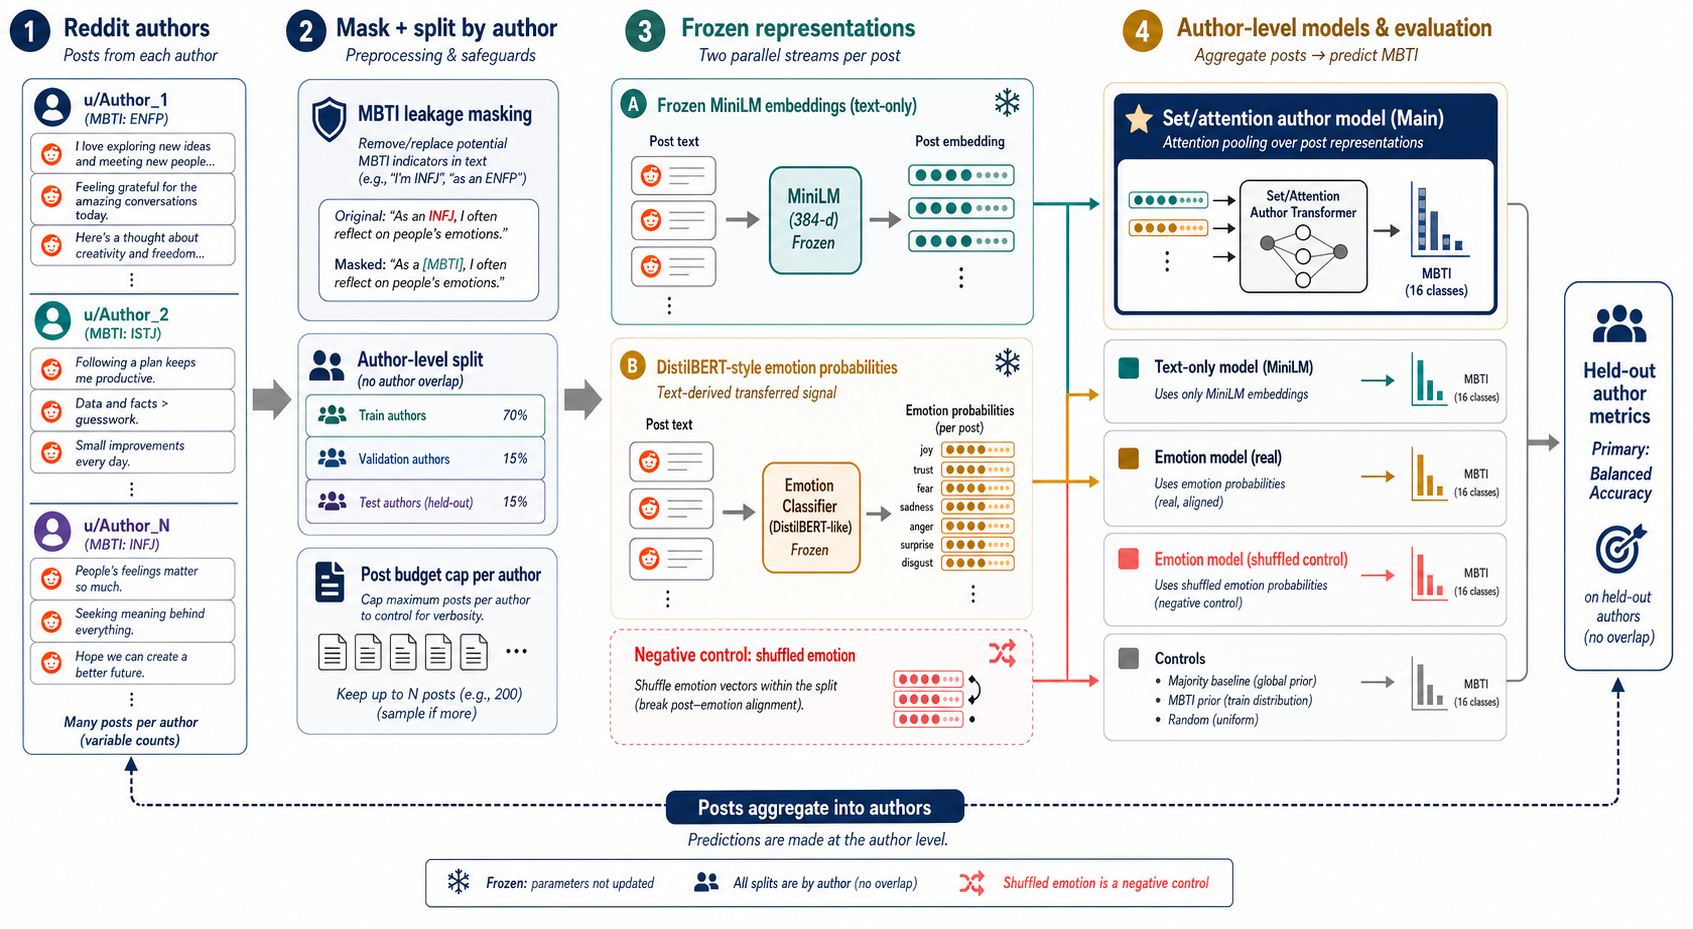

In [2]:
show_png("fig_ms4_pipeline_diagram.png")

**Figure overview.** The pipeline summarizes the experimental design used throughout the notebook. MBTI is treated as an author-level label, so the first safeguards remove direct leakage by masking explicit type mentions, split train/validation/test by author, and cap posts per author to reduce domination by unusually verbose users.

The figure also separates representation streams from model comparisons. Frozen MiniLM embeddings are the main text representation. DistilBERT-style emotion probabilities are transferred features derived from the same Reddit text, not external measurements of emotion. The controlled comparisons then test text-only, text plus real emotion, text plus shuffled emotion, and simple controls before aggregating posts into author-level predictions. The headline metric is balanced accuracy on held-out authors.

## Experiment Map

The experiments are organized in four layers.

- **Data safeguards:** mask explicit MBTI leakage, split by author, cap posts per author, and use validation-tuned thresholds with test-only reporting.
- **Baseline layer:** majority prediction, TF-IDF logistic regression, corrected GRU text models, and corrected GRU plus emotion establish what simpler text and sequence models can do.
- **Transformer author layer:** frozen MiniLM author probes test whether simple summary statistics of post embeddings are enough; set/attention author models test whether learned unordered post aggregation improves the author representation.
- **Emotion and control layer:** real emotion, shuffled emotion, activity/length controls, post-budget sensitivity, paired deltas, and seed/epoch stability checks separate suggestive emotion signal from artifacts of model capacity, verbosity, or random alignment.

This structure keeps the central comparison aligned with the scientific question: does adding aligned text-derived emotion improve held-out author prediction beyond a matched text-only representation, and does that improvement survive negative controls?

## 2. Data and Preprocessing Checks

Before modeling, we mask direct MBTI leakage, filter very short posts, keep authors with enough retained posts, cap each author at 200 posts, and split by author. These checks make sure the final scores reflect generalization to held-out users rather than memorizing obvious type strings or author identity.


In [3]:
pre_dir = ARTIFACT_DIR / "preprocessed" / "full"
summary_path = pre_dir / "summary.json"
leakage_path = pre_dir / "mbti_leakage_audit.csv"
split_balance_path = pre_dir / "split_balance.csv"

preprocess_summary = json.loads(summary_path.read_text()) if summary_path.exists() else {}
summary_keep = [
    "n_modeling_authors",
    "n_modeling_posts",
    "train_authors",
    "val_authors",
    "test_authors",
    "max_posts_per_author",
]
summary_table = pd.DataFrame([
    {key: preprocess_summary.get(key) for key in summary_keep if key in preprocess_summary}
])
display(summary_table)

if leakage_path.exists():
    display(pd.read_csv(leakage_path))
if split_balance_path.exists():
    split_balance = pd.read_csv(split_balance_path)
    display(split_balance)


,n_modeling_authors,n_modeling_posts
0,10414,1649102


,stage,n_posts,n_authors,posts_with_any_term,post_share_with_any_term,authors_with_any_term,author_share_with_any_term,posts_with_own_type,post_share_with_own_type
0,before_masking,13028455,11773,216846,0.016644,9232,0.784167,112294,0.008619
1,after_masking,13028455,11773,0,0.000000,0,0.000000,0,0.000000


,split,target,n_authors,positive_share,positive_count,negative_count
0,test,target_E,1563,0.213692,334,1229
1,test,target_S,1563,0.067179,105,1458
2,test,target_T,1563,0.397313,621,942
3,test,target_J,1563,0.397313,621,942
4,train,target_E,7289,0.213472,1556,5733
5,train,target_S,7289,0.068322,498,6791
6,train,target_T,7289,0.397585,2898,4391
7,train,target_J,7289,0.397037,2894,4395
8,val,target_E,1562,0.213188,333,1229
9,val,target_S,1562,0.069142,108,1454


The main safeguard is the author-level split: a user appears in train, validation, or test, never more than one. The leakage audit also checks that explicit MBTI strings are masked before modeling.


## 3. Why Post Budget Matters

A single Reddit post is a weak and noisy view of personality. We therefore audit truncation and compare model behavior under different retained-post budgets. This becomes central later: the strongest transformer model uses up to 200 posts per author.


,max_length,n_posts,n_authors,median_tokens,p90_tokens,p95_tokens,p99_tokens,share_posts_over_max,share_authors_with_any_truncation
0,128,1649102,10414,22.0,97.0,147.0,295.0,6.37%,90.42%
1,256,1649102,10414,22.0,97.0,147.0,295.0,1.46%,59.62%


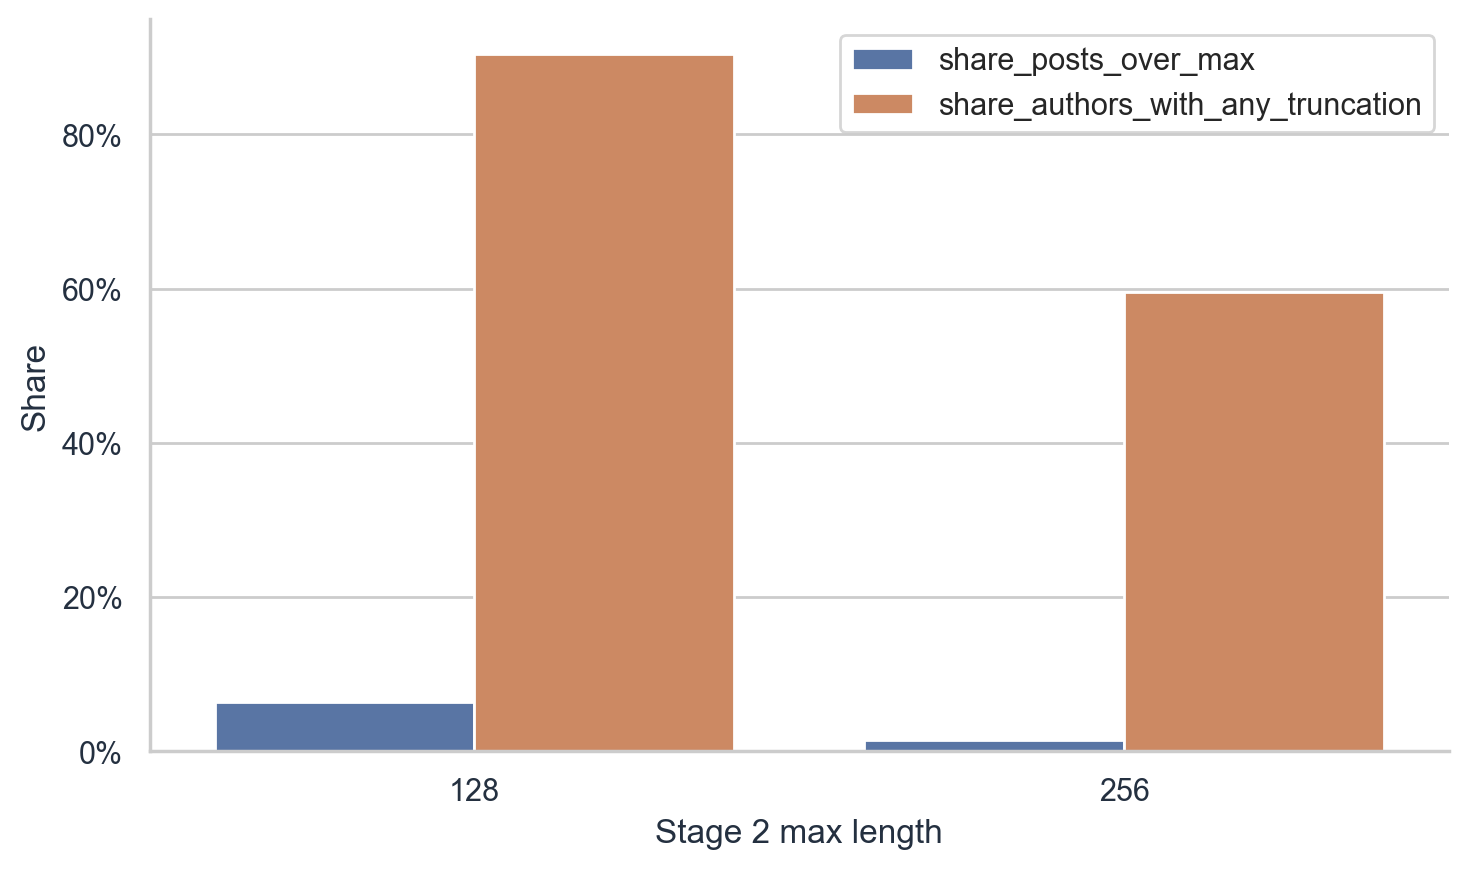

,max_length,run_id,epochs_completed,best_val_loss,final_train_loss,test_mean_balanced_accuracy,test_mean_f1,parameter_count
0,128,stage2_text_gru_full,4,0.7200,0.7007,0.5964,0.4225,3947588
1,256,stage2_text_gru_len256_full,3,0.7262,0.7209,0.5029,0.0925,3947588


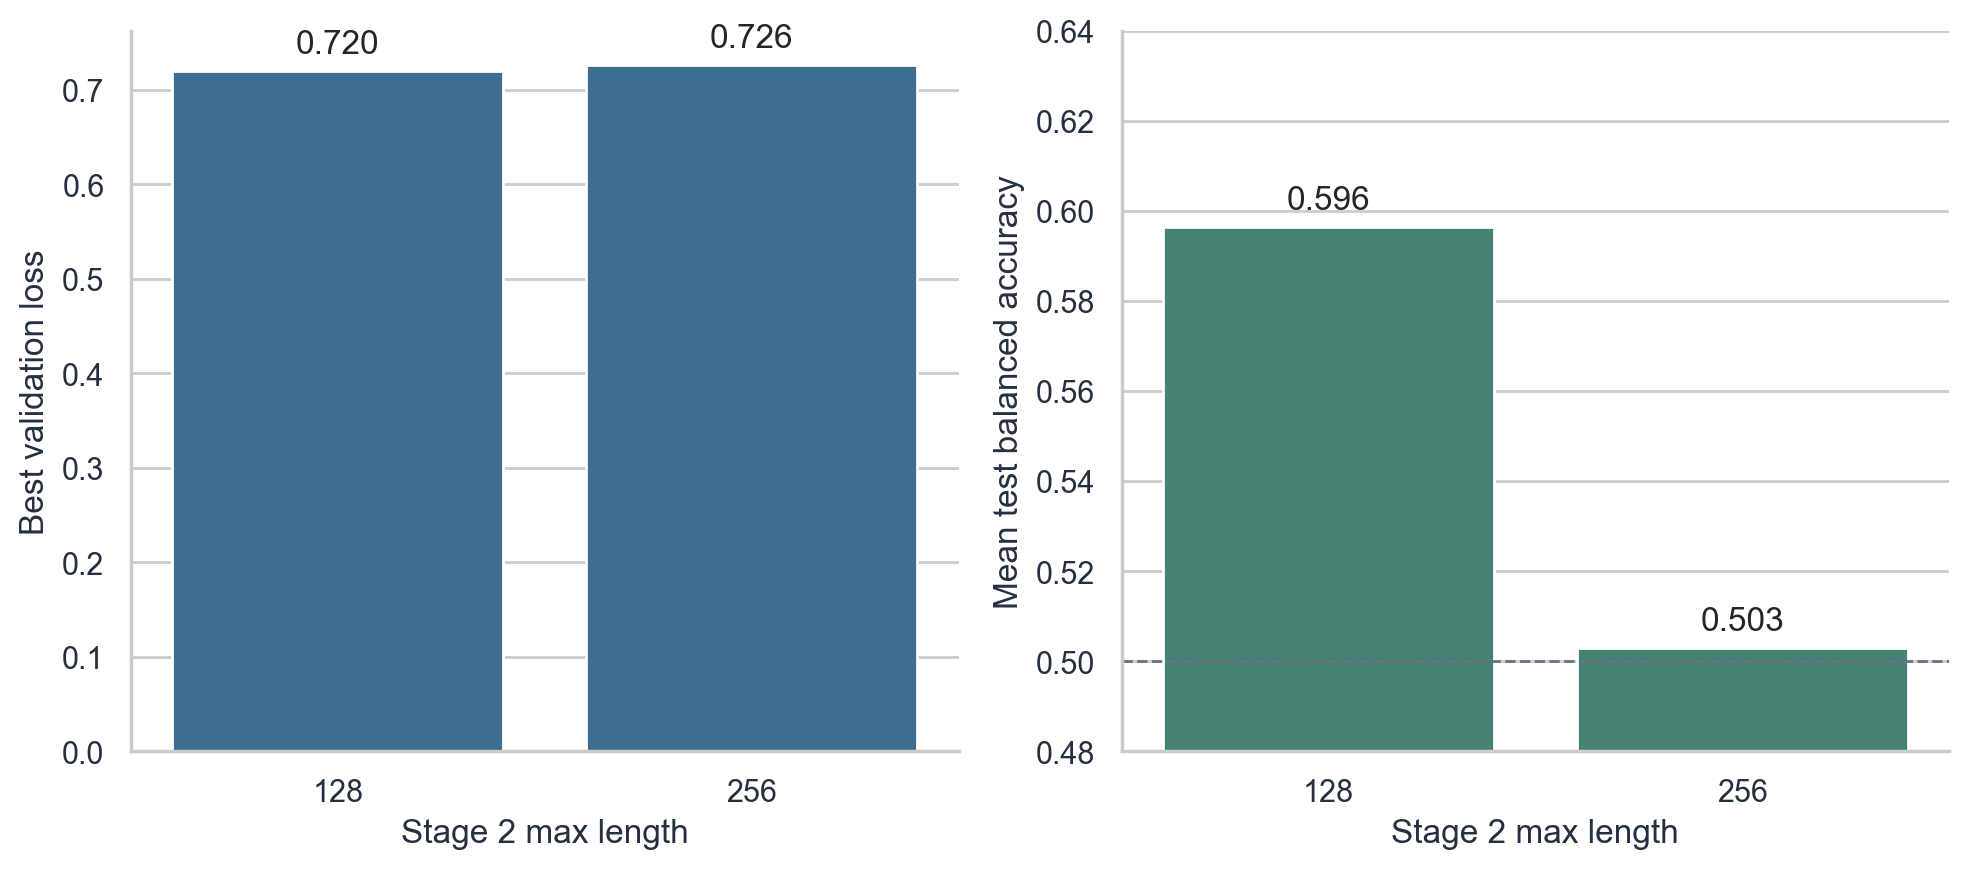

In [4]:
token_length_sensitivity = pd.read_csv(REPORT_RESULTS_DIR / "token_length_sensitivity.csv")
max_length_training_sensitivity = pd.read_csv(REPORT_RESULTS_DIR / "max_length_training_sensitivity.csv")

display(token_length_sensitivity.style.format({
    "median_tokens": "{:.1f}",
    "p90_tokens": "{:.1f}",
    "p95_tokens": "{:.1f}",
    "p99_tokens": "{:.1f}",
    "share_posts_over_max": "{:.2%}",
    "share_authors_with_any_truncation": "{:.2%}",
}))
show_png("fig_token_length_sensitivity.png")

display(max_length_training_sensitivity.style.format({
    "best_val_loss": "{:.4f}",
    "final_train_loss": "{:.4f}",
    "test_mean_balanced_accuracy": "{:.4f}",
    "test_mean_f1": "{:.4f}",
}))
show_png("fig_max_length_training_sensitivity.png")


The length audit shows that truncation is real, but simply extending the GRU input length does not solve the problem. This motivates representing an author with many post embeddings instead of relying on a single sequence model.


## 4. Baseline Layer: What Did the Older Models Show?

The baseline layer includes majority prediction, TF-IDF logistic regression, and corrected GRU models. These are important because they set the floor: any new transformer approach should beat both the trivial imbalance baseline and a strong lexical author baseline.


,model_id,model_name,balanced_accuracy,f1,minority_recall,roc_auc,average_precision
0,linear_tfidf_author,TF-IDF Logistic,0.6512,0.4609,0.5904,0.7100,0.4643
1,stage2_text_emotion_gru,GRU Text + Emotion,0.6223,0.4336,0.5904,0.6833,0.4451
2,stage2_text_gru_sqrt,GRU Text,0.5964,0.4225,0.6318,0.6591,0.4132
3,stage2_text_gru_inverse,GRU Text Inverse Weight,0.5855,0.3972,0.5546,0.6265,0.3821
4,majority_author,Majority,0.5000,0.0000,0.0000,0.5000,0.2689


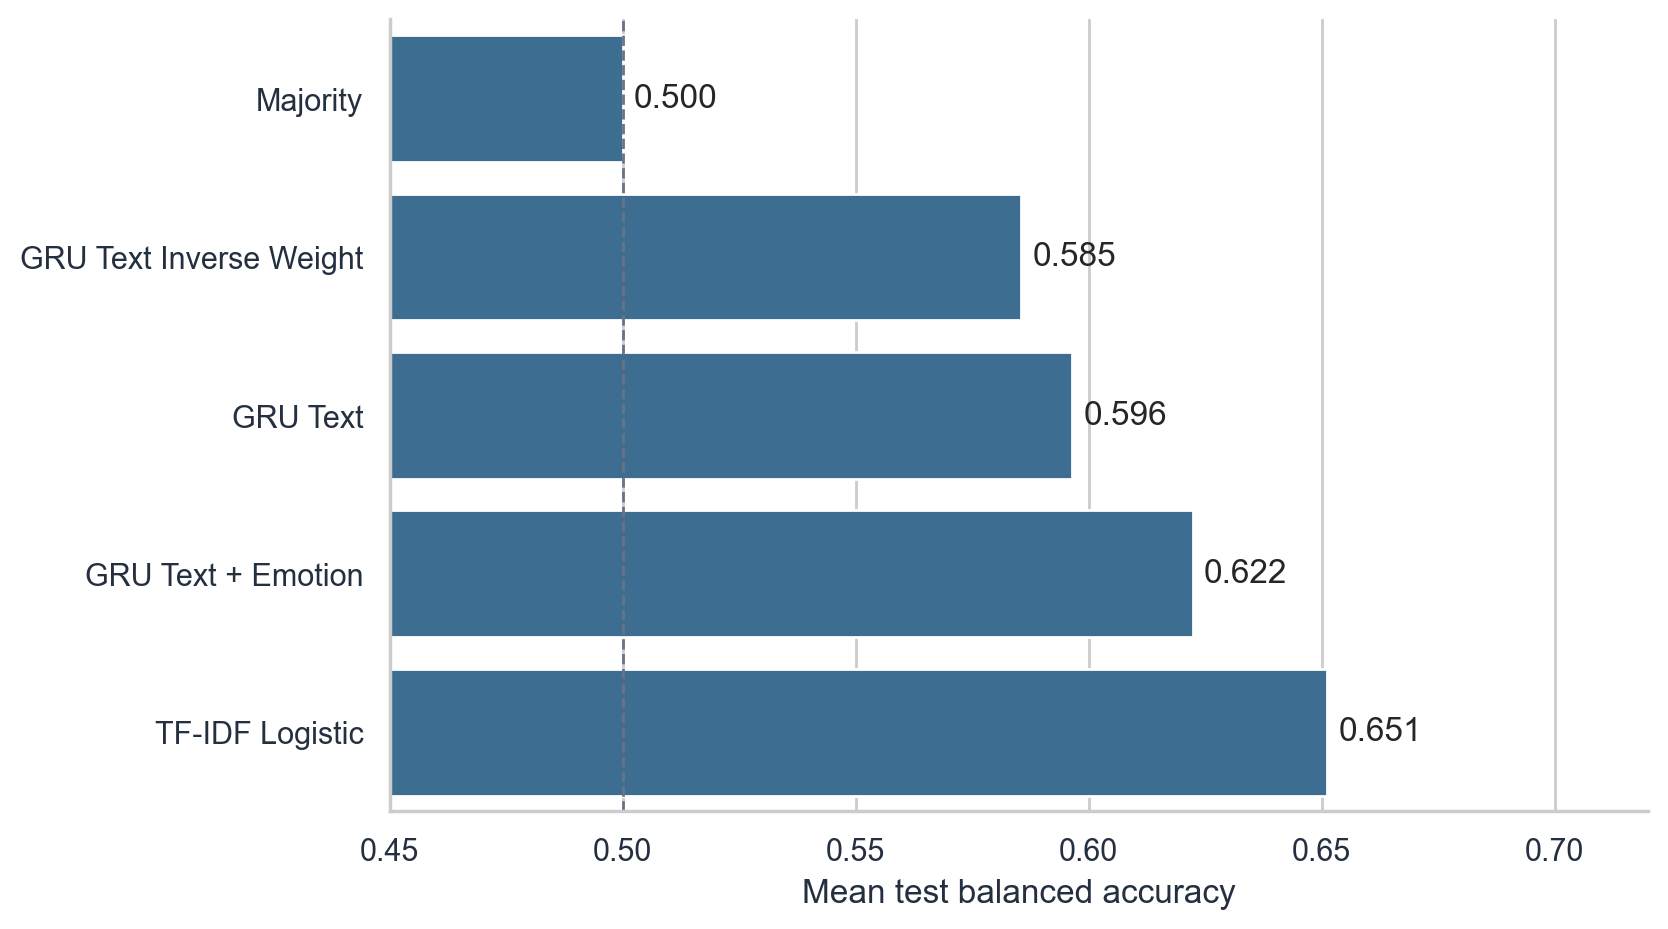

In [5]:
model_summary = pd.read_csv(REPORT_RESULTS_DIR / "model_summary.csv")
display(model_summary.style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "minority_recall": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))
show_png("fig_model_summary_balanced_accuracy.png")


The corrected GRU plus emotion improves over corrected GRU text-only, but TF-IDF logistic regression remains stronger. That makes the baseline result useful but not sufficient: the final model needs to match the author-level structure of the task, not just add neural complexity.


## 5. Per-Dimension Performance

MBTI dimensions are not equally difficult. Looking only at an average can hide whether a model improves broadly or only on one dimension.


,model_name,target,balanced_accuracy,f1,minority_recall,roc_auc,average_precision
12,TF-IDF Logistic,target_E,0.6694,0.4675,0.6138,0.7331,0.4312
36,GRU Text + Emotion,target_E,0.6119,0.4004,0.5599,0.6777,0.3831
20,GRU Text,target_E,0.5958,0.3795,0.5000,0.6528,0.3427
28,GRU Text Inverse Weight,target_E,0.5890,0.3764,0.5449,0.6325,0.3190
4,Majority,target_E,0.5000,0.0000,0.0000,0.5000,0.2137
15,TF-IDF Logistic,target_J,0.6271,0.5381,0.5121,0.6845,0.5941
39,GRU Text + Emotion,target_J,0.6191,0.5484,0.5652,0.6680,0.5842
23,GRU Text,target_J,0.5656,0.5498,0.7150,0.6095,0.5056
31,GRU Text Inverse Weight,target_J,0.5606,0.4587,0.4428,0.5850,0.4731
7,Majority,target_J,0.5000,0.0000,0.0000,0.5000,0.3973


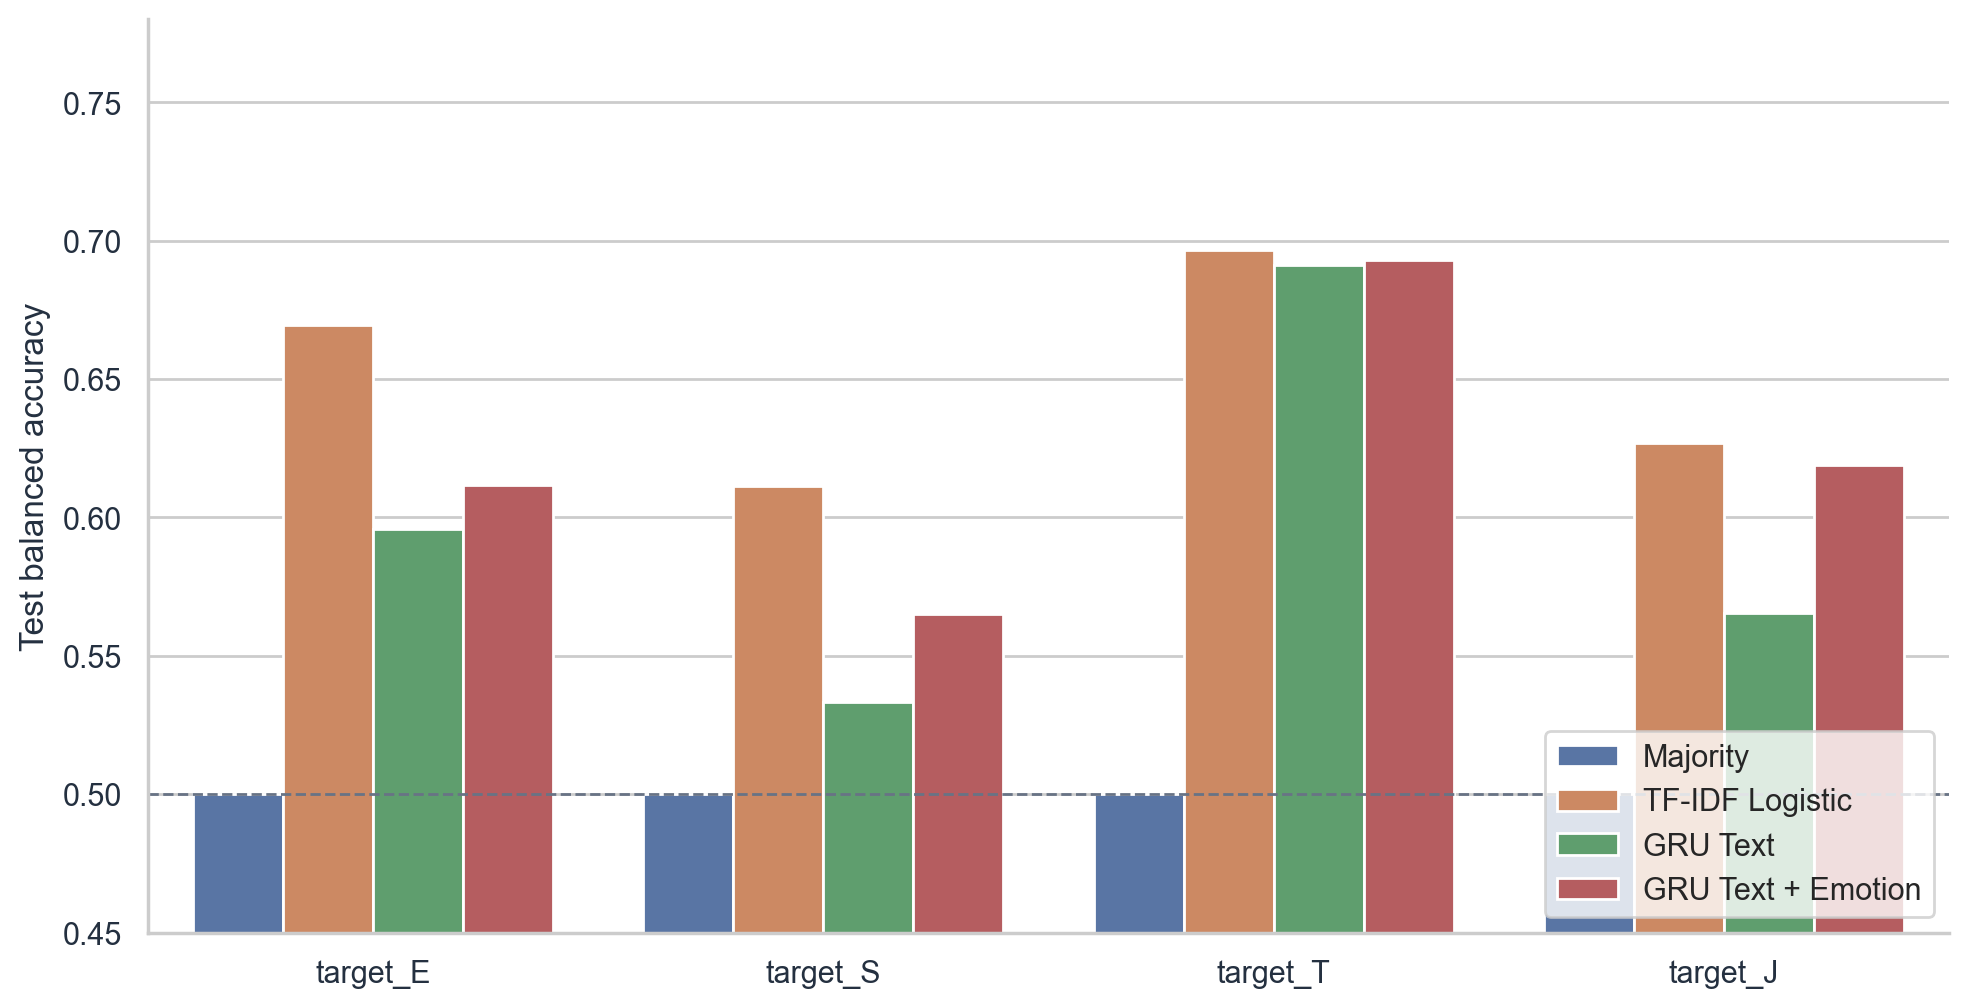

In [6]:
all_metrics = pd.read_csv(REPORT_RESULTS_DIR / "all_model_metrics.csv")
test_metrics = all_metrics.loc[all_metrics["split"] == "test"].copy()
cols = ["model_name", "target", "balanced_accuracy", "f1", "minority_recall", "roc_auc", "average_precision"]
display(test_metrics[cols].sort_values(["target", "balanced_accuracy"], ascending=[True, False]).style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "minority_recall": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))
show_png("fig_target_balanced_accuracy.png")


Performance varies by MBTI dimension, so a single undifferentiated accuracy claim would be misleading. Balanced accuracy is the headline metric because several dimensions are imbalanced.


## 6. What Did Emotion Add in the GRU Baseline?

The first emotion test asks whether DistilBERT emotion probabilities help after fixing class weighting, author aggregation, and threshold tuning for the GRU baseline.


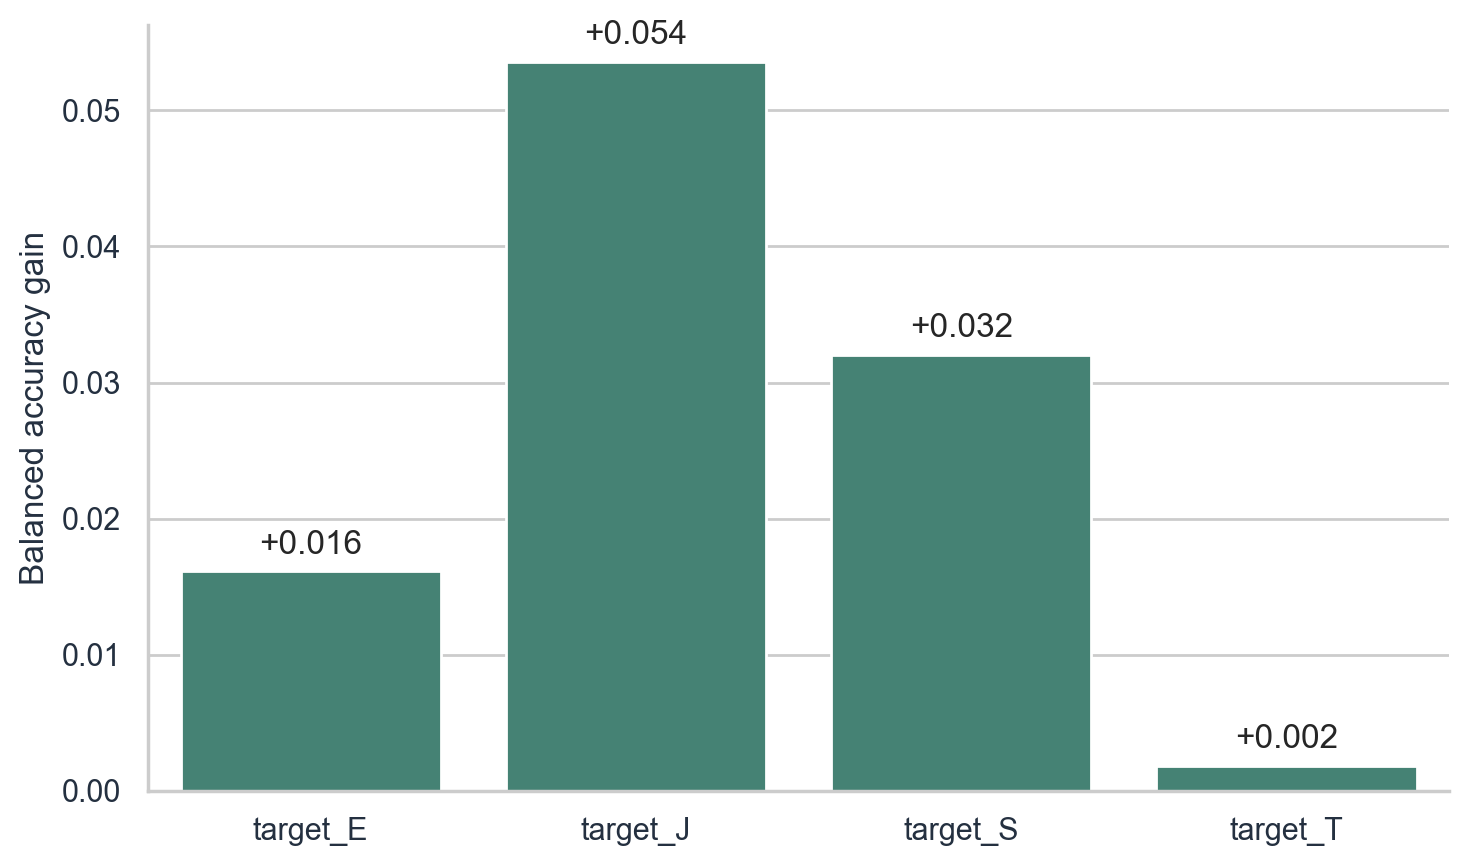

In [7]:
show_png("fig_emotion_gain_by_target.png")


The GRU emotion result is a useful motivation, not the final evidence. Emotion probabilities are derived from the same text, and the GRU is not the strongest model family.


## 7. Emotion Features Are Transferred Across Domains

The emotion model was trained on a source emotion dataset and applied to Reddit posts. The source and target distributions are not identical, so emotion features must be interpreted as transferred text-derived representations.


,source,emotion,share
0,Emotion source labels,sadness,0.167
1,Emotion source labels,joy,0.167
2,Emotion source labels,love,0.167
3,Emotion source labels,anger,0.167
4,Emotion source labels,fear,0.167
5,Emotion source labels,surprise,0.167
6,Reddit inferred,sadness,0.113
7,Reddit inferred,joy,0.496
8,Reddit inferred,love,0.025
9,Reddit inferred,anger,0.274


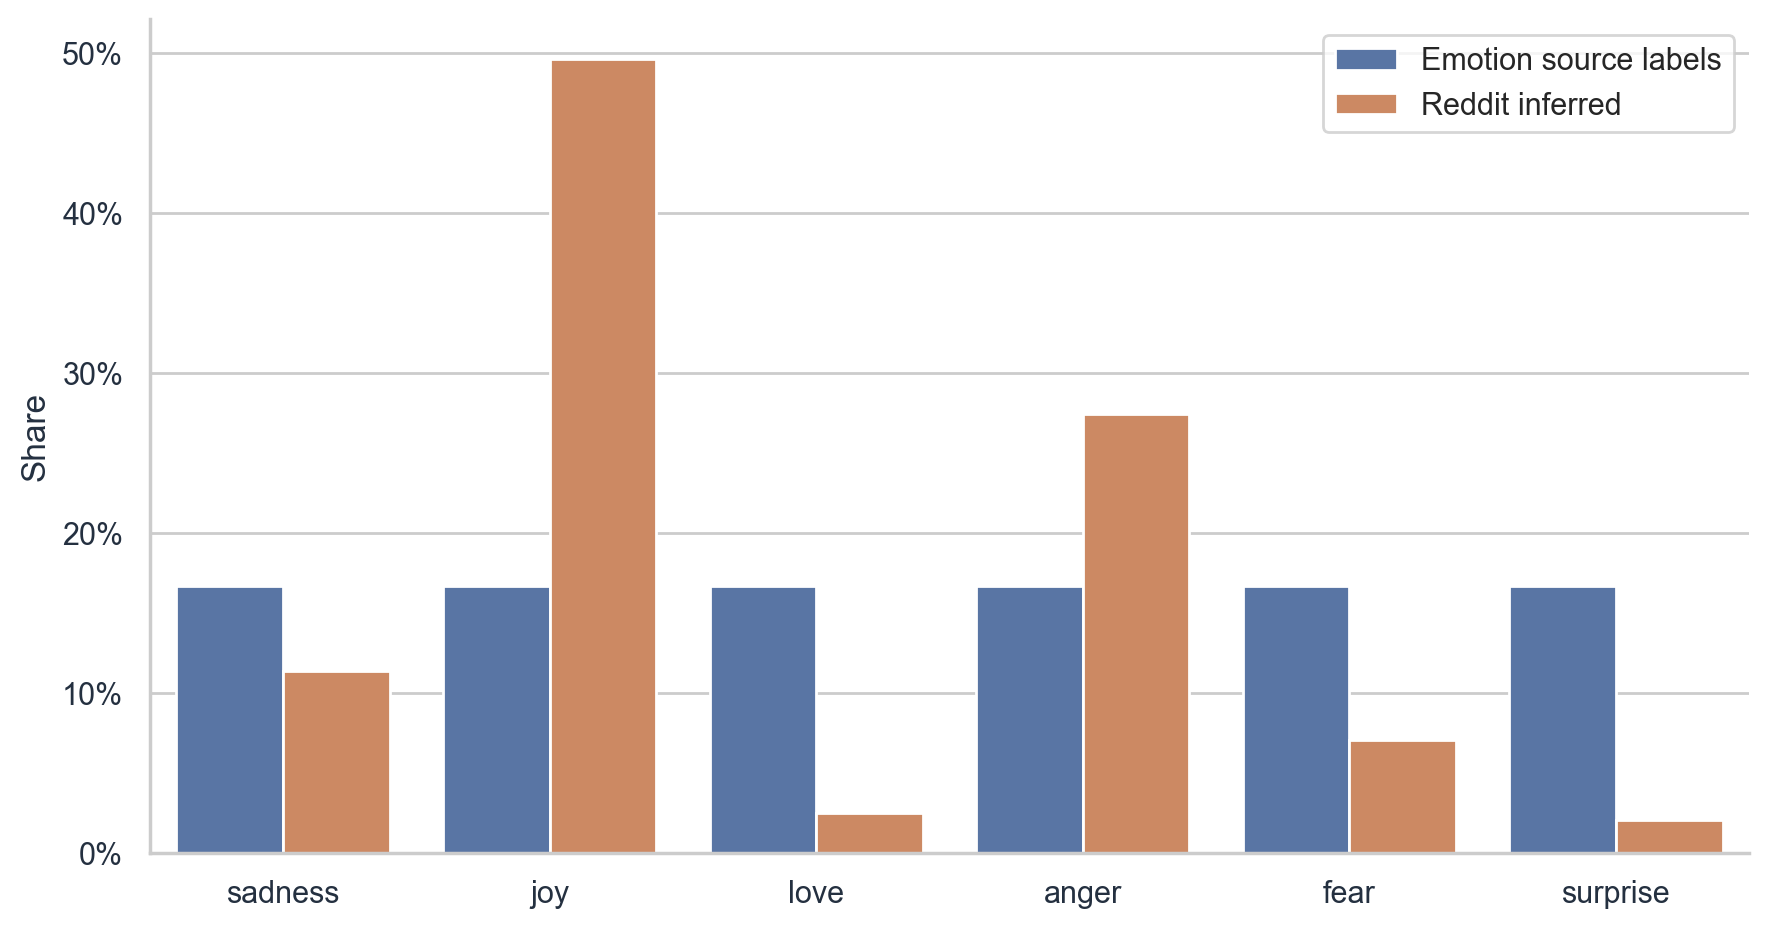

In [8]:
emotion_dist = pd.read_csv(REPORT_RESULTS_DIR / "emotion_distribution_source_vs_reddit.csv")
display(emotion_dist.style.format({"share": "{:.3f}"}))
show_png("fig_source_vs_reddit_emotion_distribution.png")


The source-to-Reddit distribution shift is a reminder to treat emotion probabilities as transferred text features, not as ground-truth measurements of a user's emotional state.


## 8. Main Model Shift: Author-Level Transformer Representations

The updated MS4 direction uses frozen MiniLM post embeddings and author-level models. The frozen-probe path summarizes each author's post embeddings with simple statistics, while the set/attention path lets the model learn how to aggregate a user's unordered set of posts.

The shuffled-emotion variant is the key negative control. It keeps the marginal emotion distribution but breaks the alignment between a user's posts and that user's emotion features. If shuffled emotion performs about as well as real emotion, the result should not be interpreted as strong evidence for author-aligned emotion signal.


## 9. Frozen Transformer Author Probes

First, we freeze MiniLM, summarize each author's post embeddings, and train lightweight author-level classifiers. This tests whether transformer text representations alone are enough to beat the earlier baselines.


,model_id,model_name,balanced_accuracy,f1,minority_recall,roc_auc,average_precision,post_budget
0,frozen_text_mean_std,Frozen Text,0.6293,0.4285,0.5866,0.6747,0.4172,nan
1,frozen_text_real_emotion_controls,Frozen Text + Real Emotion + Controls,0.6289,0.4417,0.5945,0.6742,0.4208,nan
2,frozen_text_shuffled_emotion,Frozen Text + Shuffled Emotion,0.6274,0.4411,0.5999,0.6741,0.4162,nan
3,frozen_text_controls,Frozen Text + Controls,0.6260,0.4442,0.6022,0.6724,0.4190,nan
4,frozen_text_real_emotion,Frozen Text + Real Emotion,0.6233,0.4371,0.5769,0.6738,0.4192,nan
5,frozen_emotion_only,Emotion Only,0.5651,0.3942,0.5639,0.5821,0.3370,nan


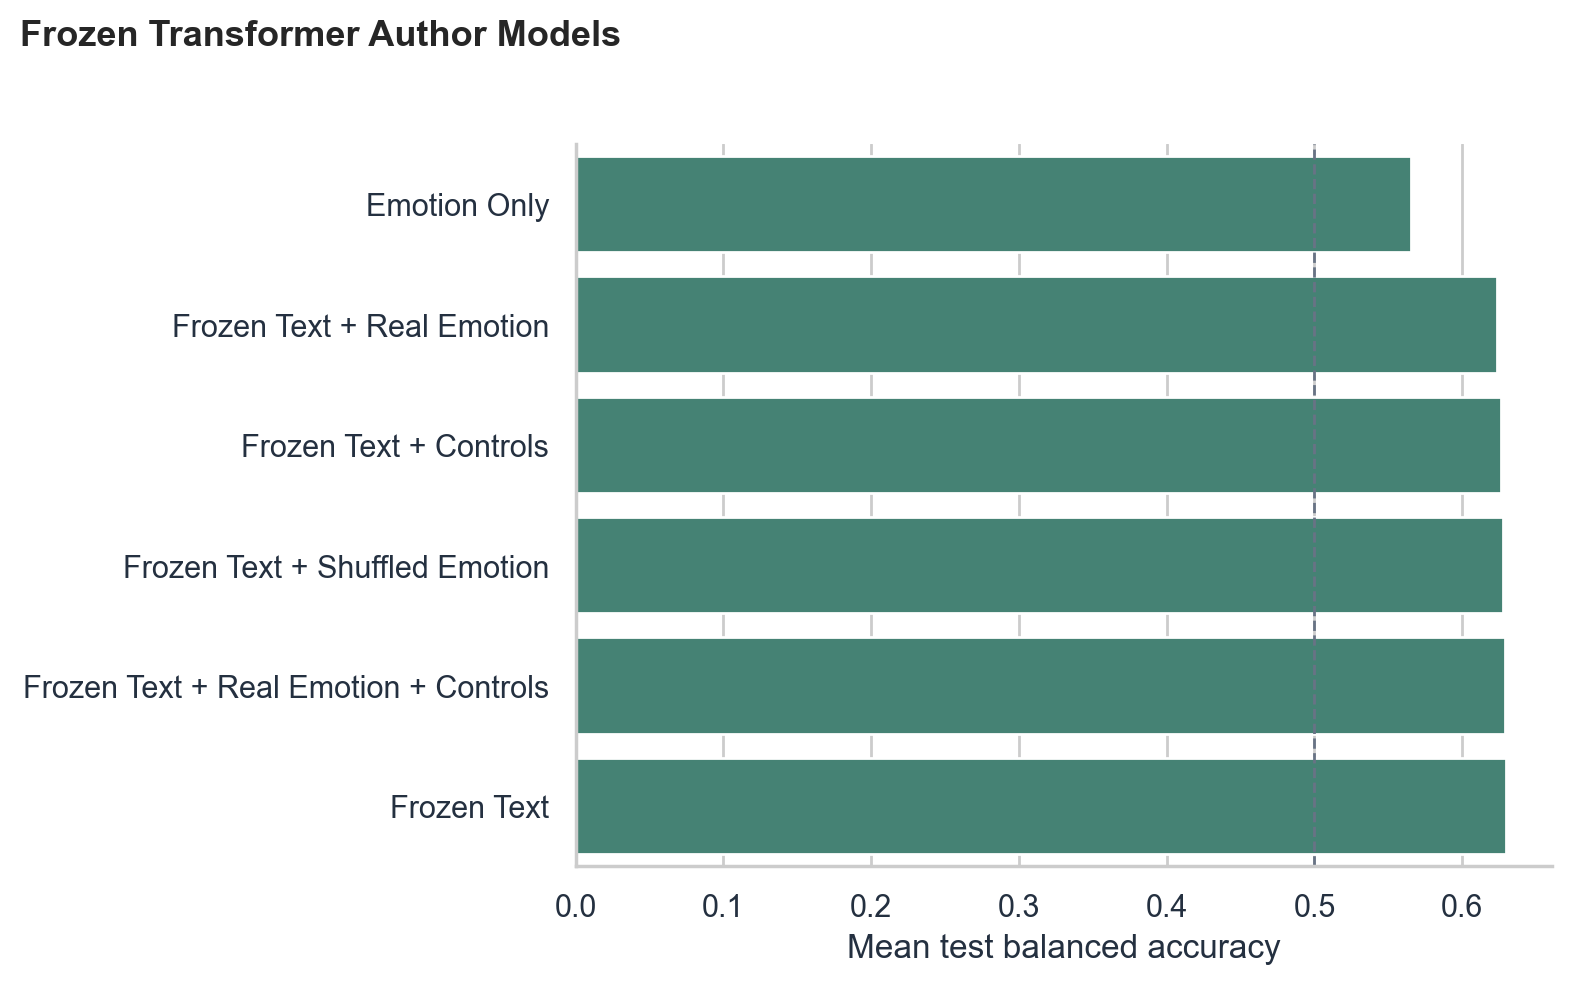

In [9]:
frozen_transformer_summary = pd.read_csv(REPORT_RESULTS_DIR / "frozen_transformer_model_summary.csv")
display(frozen_transformer_summary.style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "minority_recall": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))
show_png("fig_frozen_transformer_author_models.png")


Frozen MiniLM summaries are competitive with the corrected GRU models, but they do not beat TF-IDF. Emotion-only features are above the majority baseline, which means the transferred emotion representation contains some author-level information, but the real, shuffled, and control variants cluster closely together. Simple summary pooling of frozen embeddings is therefore not enough to make a strong emotion-specific claim.

## 10. Set/Attention Author Transformer Results

The set/attention model learns an author representation from a user's post embeddings without imposing a fake temporal order. We compare text-only, real emotion, shuffled emotion, controls, and post budgets of 50 versus 200 posts. The p50 budget uses a deterministic seed/hash post order within each author, so it is a stable pseudo-random retained-post budget rather than an artifact of text sorting.


,model_id,model_name,balanced_accuracy,f1,minority_recall,roc_auc,average_precision,post_budget
0,set_attention_text_controls_p200,Set Attention Text + Controls p=200,0.6879,0.5066,0.6514,0.7517,0.5172,200
1,set_attention_text_p200,Set Attention Text p=200,0.6784,0.4898,0.7066,0.7450,0.5032,200
2,set_attention_text_real_emotion_controls_p200,Set Attention Text + Real Emotion + Controls p=200,0.6762,0.4858,0.6714,0.7439,0.5055,200
3,set_attention_text_shuffled_emotion_p200,Set Attention Text + Shuffled Emotion p=200,0.6716,0.4964,0.6324,0.7452,0.5039,200
4,set_attention_text_real_emotion_p200,Set Attention Text + Real Emotion p=200,0.6715,0.4843,0.6324,0.7405,0.5001,200
5,set_attention_text_controls_p50,Set Attention Text + Controls p=50,0.6417,0.4621,0.5662,0.7062,0.4530,50
6,set_attention_text_shuffled_emotion_p50,Set Attention Text + Shuffled Emotion p=50,0.6389,0.4495,0.6255,0.6935,0.4418,50
7,set_attention_text_p50,Set Attention Text p=50,0.6373,0.4547,0.6622,0.6935,0.4412,50
8,set_attention_text_real_emotion_controls_p50,Set Attention Text + Real Emotion + Controls p=50,0.6298,0.4486,0.6324,0.6841,0.4270,50
9,set_attention_text_real_emotion_p50,Set Attention Text + Real Emotion p=50,0.6280,0.4471,0.6900,0.6958,0.4435,50


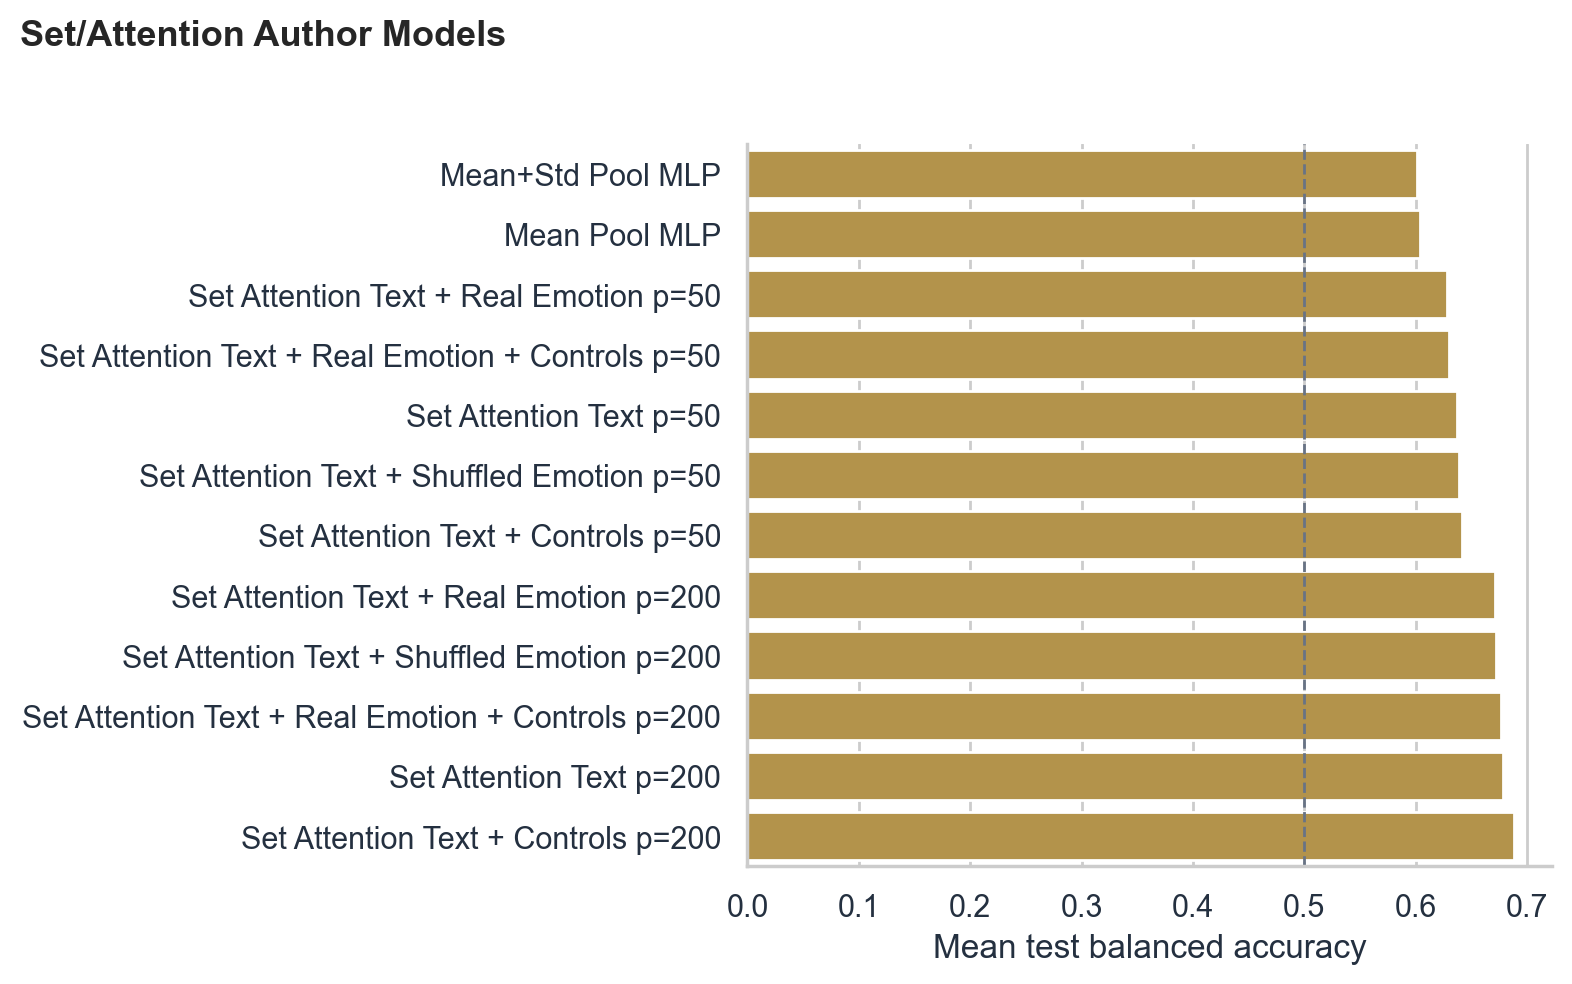

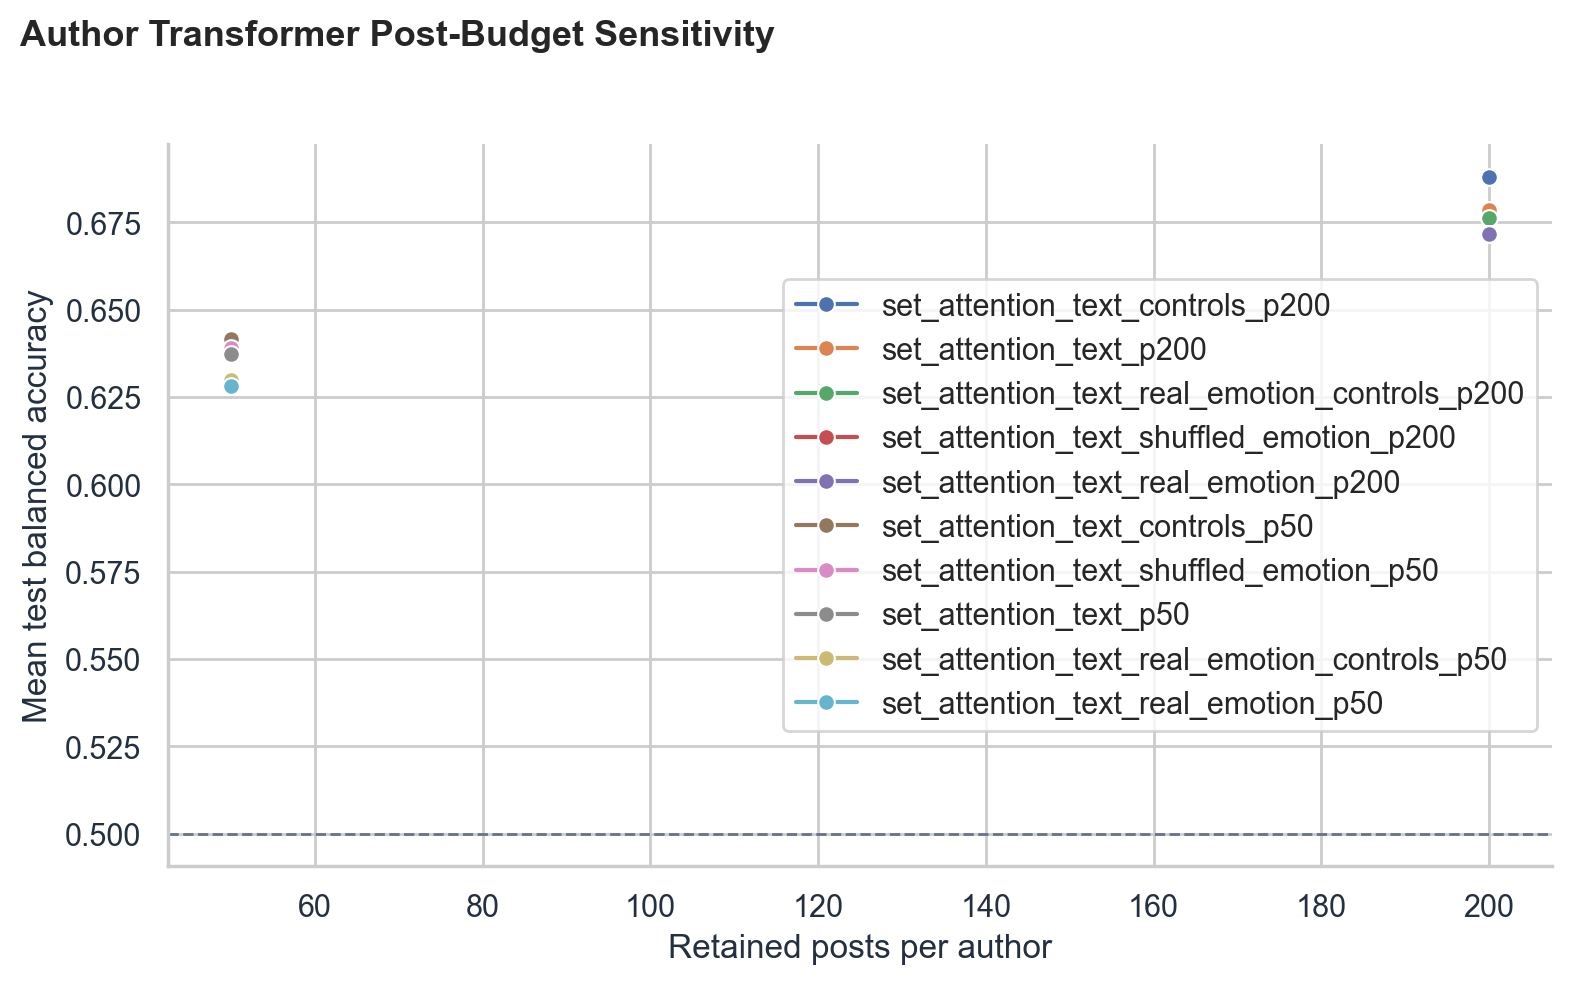

In [10]:
set_attention_summary = pd.read_csv(REPORT_RESULTS_DIR / "set_attention_model_summary.csv")
display(set_attention_summary.style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "minority_recall": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
    "post_budget": "{:.0f}",
}))
show_png("fig_set_attention_author_models.png")
show_png("fig_set_attention_post_budget.png")


The 200-post set/attention family is the strongest model family in the notebook. Two patterns matter. First, using 200 posts is much stronger than using 50 posts, so author history is central to the task. Second, learned set/attention aggregation beats the mean-pooling MLP baselines, which supports the move away from simple author summaries. With post-level controls standardized separately within each post budget using train-split statistics, the controls variant is the highest p200 run. This makes the controls diagnostic more important, not less: activity and length information can help the author model, while adding real emotion does not improve over the matched text-only p200 comparison.

### p200 Set/Attention Error Profile

The confusion matrices below are for the p200 text-only set/attention author model, using validation-tuned thresholds and held-out test authors. This is the cleanest error-profile view for the main author-level formulation because it does not mix in the diagnostic control features or the unstable emotion increment.

predicted_label        0    1
target   true_label          
target_E 0           825  404
         1            97  237
target_J 0           558  384
         1           195  426
target_S 0           872  586
         1            31   74
target_T 0           696  246
         1           170  451

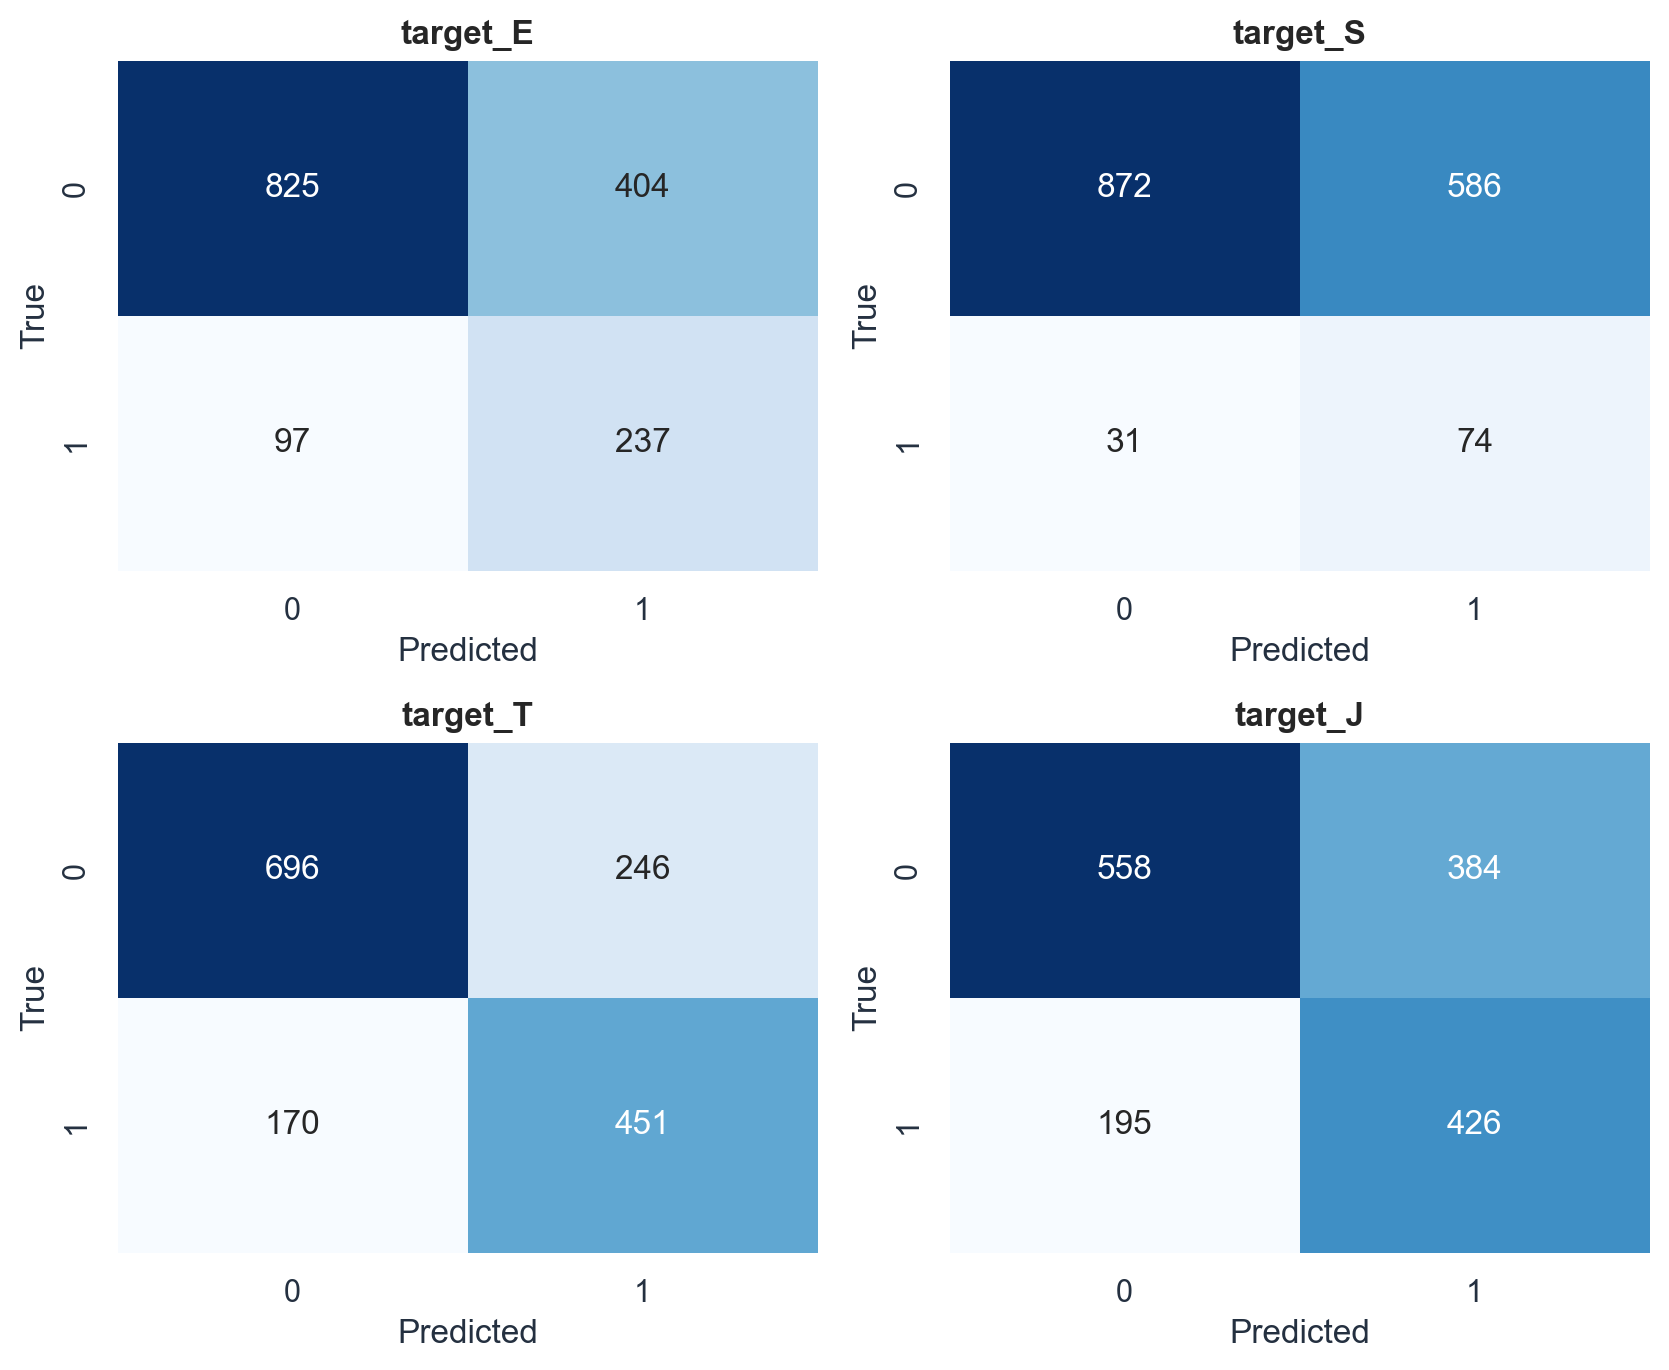

In [11]:
set_attention_confusions = pd.read_csv(REPORT_RESULTS_DIR / "set_attention_p200_confusion_matrices.csv")
display(set_attention_confusions.pivot_table(
    index=["target", "true_label"],
    columns="predicted_label",
    values="count",
    aggfunc="sum",
).fillna(0).astype(int))
show_png("fig_set_attention_p200_confusion_matrices.png")

## 11. Does Emotion Add Signal Beyond Text?

The strict test is not whether an emotion model performs above chance. The strict test is whether **text + real emotion** beats the matched **text-only** model more than **text + shuffled emotion** does.


,comparison,metric,target,point_estimate,ci_lower,ci_upper,n_bootstrap,n_authors
4,Frozen transformer: real emotion minus text,balanced_accuracy,mean,-0.0060,-0.0155,+0.0029,2000,1563
9,Frozen transformer: shuffled emotion minus text,balanced_accuracy,mean,-0.0019,-0.0120,+0.0081,2000,1563
14,Set attention p=50: real emotion minus text,balanced_accuracy,mean,-0.0093,-0.0211,+0.0026,2000,1563
19,Set attention p=50: shuffled emotion minus text,balanced_accuracy,mean,+0.0016,-0.0131,+0.0157,2000,1563
24,Set attention p=200: real emotion minus text,balanced_accuracy,mean,-0.0069,-0.0191,+0.0041,2000,1563
29,Set attention p=200: shuffled emotion minus text,balanced_accuracy,mean,-0.0067,-0.0200,+0.0052,2000,1563


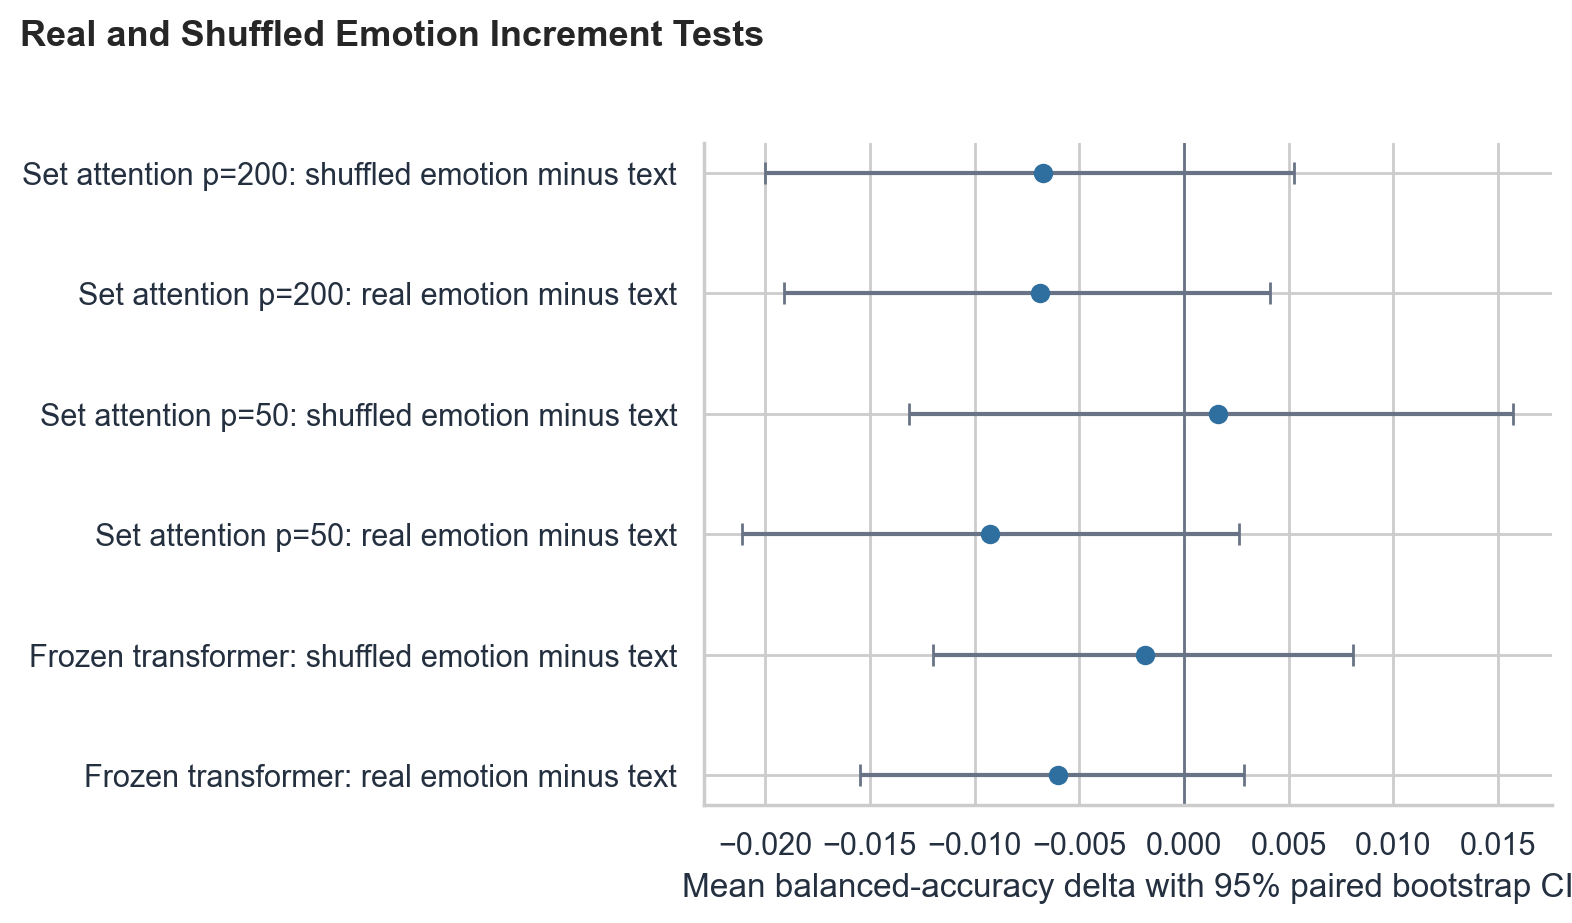

In [12]:
transformer_deltas = pd.read_csv(REPORT_RESULTS_DIR / "transformer_emotion_deltas.csv")
mean_deltas = transformer_deltas.loc[transformer_deltas["target"] == "mean"].copy()
display(mean_deltas.style.format({
    "point_estimate": "{:+.4f}",
    "ci_lower": "{:+.4f}",
    "ci_upper": "{:+.4f}",
}))
show_png("fig_transformer_emotion_deltas.png")


The headline p200 matched comparison is not positive for real emotion. Real emotion minus text-only is **-0.0069** mean balanced accuracy, with a 95% bootstrap interval of **[-0.0191, 0.0041]**. Shuffled emotion is closer to text-only and its interval crosses zero. The defensible conclusion is therefore stricter than any positive emotion-increment story: real emotion does not show a reliable improvement in the main p200 set/attention comparison, and the broader evidence supports author-level aggregation rather than a robust emotion-specific increment.

## 12. Stability Checks for the p200 Set/Attention Family

Because p200 is the high-history setting in the planned post-budget comparison, we ran two extra seeds and max-epoch-cap sensitivity for the three key p200 variants: text-only, real emotion, and shuffled emotion. Early stopping remains enabled, so the 10- and 20-epoch rows should be read as maximum-epoch caps under the same early-stopping rule, not as models forced to train for the full number of epochs. These are robustness checks for the author-level formulation, not a test-set-driven model selection step.


,model_id,model_name,post_budget,epochs,n_seeds,mean_balanced_accuracy,std_balanced_accuracy,min_balanced_accuracy,max_balanced_accuracy
0,set_attention_text_p200,Set Attention Text p=200,200,5,3,0.6792,0.0023,0.6774,0.6818
1,set_attention_text_shuffled_emotion_p200,Set Attention Text + Shuffled Emotion p=200,200,5,3,0.6781,0.0058,0.6716,0.6828
2,set_attention_text_real_emotion_p200,Set Attention Text + Real Emotion p=200,200,5,3,0.6732,0.0016,0.6715,0.6748


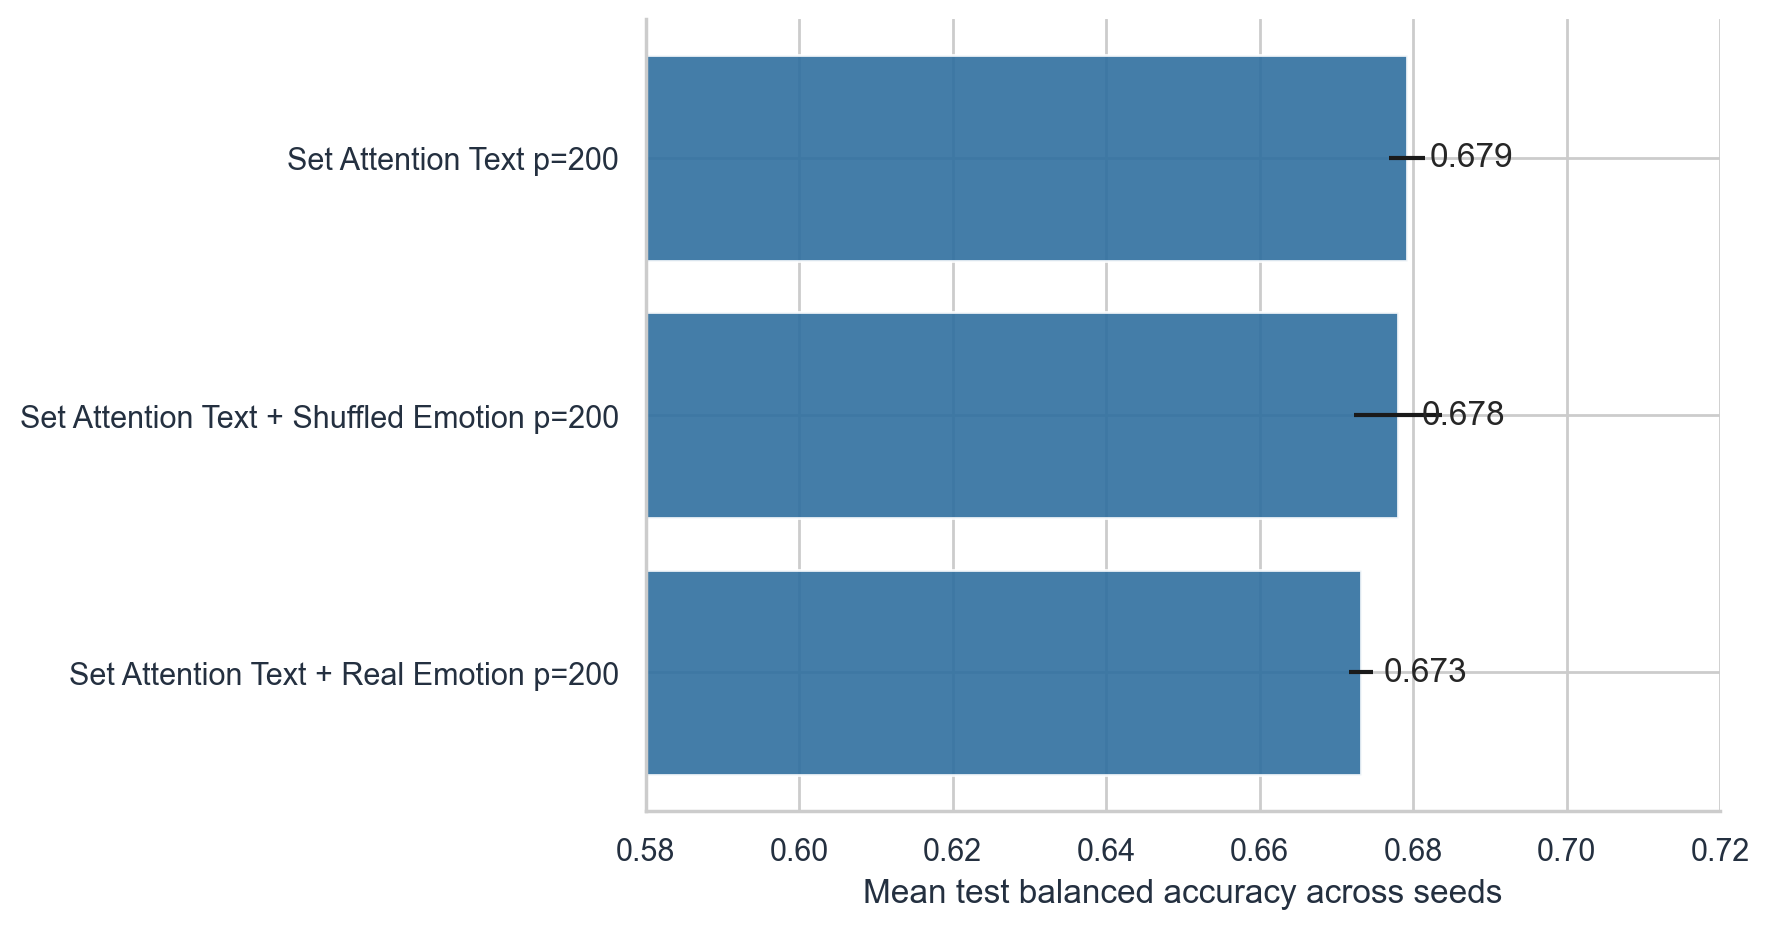

,analysis,run_id,seed,epochs,model_name,balanced_accuracy,f1,roc_auc
0,epoch_sensitivity,p200_e10_seed209066,209066,10,Set Attention Text + Shuffled Emotion p=200,0.6907,0.5004,0.7563
1,epoch_sensitivity,p200_e10_seed209066,209066,10,Set Attention Text p=200,0.6784,0.4898,0.7450
2,epoch_sensitivity,p200_e10_seed209066,209066,10,Set Attention Text + Real Emotion p=200,0.6715,0.4843,0.7405
3,epoch_sensitivity,p200_e20_seed209066,209066,20,Set Attention Text + Shuffled Emotion p=200,0.6907,0.5004,0.7563
4,epoch_sensitivity,p200_e20_seed209066,209066,20,Set Attention Text p=200,0.6784,0.4898,0.7450
5,epoch_sensitivity,p200_e20_seed209066,209066,20,Set Attention Text + Real Emotion p=200,0.6715,0.4843,0.7405
6,multi_seed,p200_e5_seed209067,209067,5,Set Attention Text + Shuffled Emotion p=200,0.6828,0.4930,0.7449
7,multi_seed,p200_e5_seed209067,209067,5,Set Attention Text p=200,0.6774,0.4837,0.7439
8,multi_seed,p200_e5_seed209067,209067,5,Set Attention Text + Real Emotion p=200,0.6748,0.4952,0.7410
9,multi_seed,p200_e5_seed209068,209068,5,Set Attention Text p=200,0.6818,0.4977,0.7430


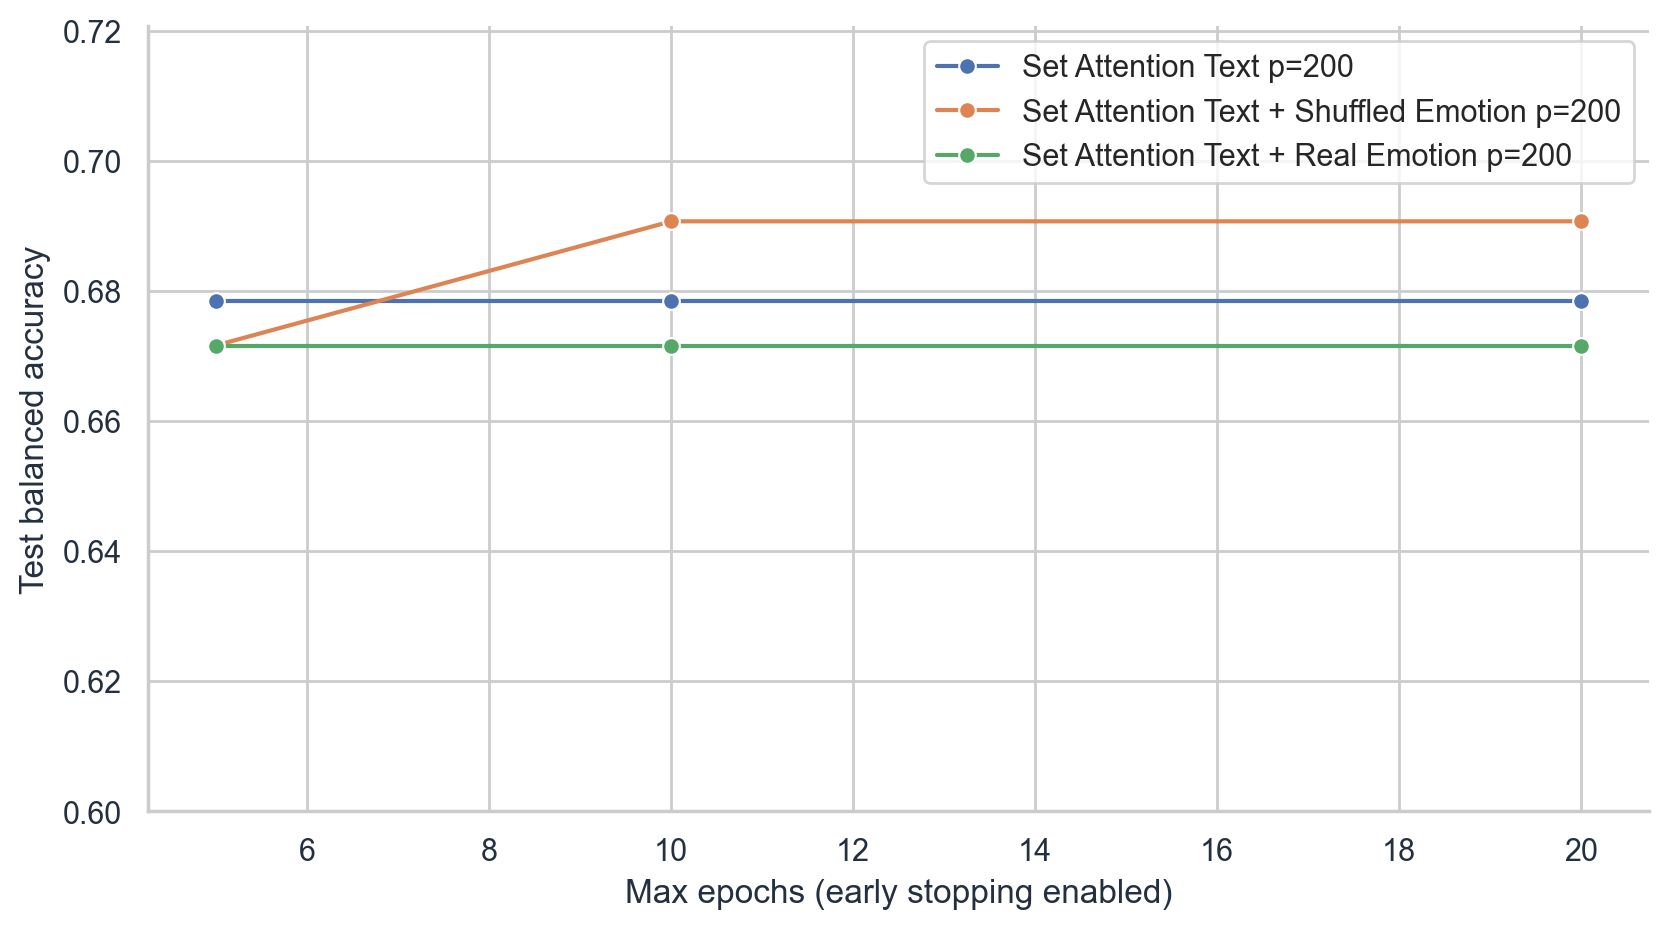

In [13]:
stability = pd.read_csv(REPORT_RESULTS_DIR / "set_attention_seed_stability.csv")
supplemental = pd.read_csv(REPORT_RESULTS_DIR / "set_attention_supplemental_summary.csv")

display(stability.style.format({
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}",
    "min_balanced_accuracy": "{:.4f}",
    "max_balanced_accuracy": "{:.4f}",
}))
show_png("fig_set_attention_seed_stability.png")

compact_supplemental = supplemental[[
    "analysis", "run_id", "seed", "epochs", "model_name", "balanced_accuracy", "f1", "roc_auc"
]].copy()
display(compact_supplemental.style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
}))
show_png("fig_set_attention_epoch_sensitivity.png")


The stability checks support the author-level set/attention direction, but they weaken a strong emotion-specific claim. Across extra seeds, the three p200 variants are close and text-only has the highest mean. Under larger max-epoch caps with early stopping enabled, shuffled emotion improves while real emotion remains below text-only, and the 10- and 20-epoch rows are identical because early stopping selects the same best checkpoint. This is why the final story emphasizes the author-level transformer formulation rather than an emotion increment.

## 13. Baseline Uncertainty and Thresholding

For the baseline layer, we also estimate bootstrap uncertainty and inspect threshold tuning. These diagnostics keep the evaluation honest under class imbalance.


,model_name,point_estimate,ci_lower,ci_upper,n_test_authors,n_bootstrap
2,TF-IDF Logistic,0.6512,0.6341,0.6673,1563,2000
8,GRU Text + Emotion,0.6223,0.6048,0.6398,1563,2000
4,GRU Text,0.5964,0.5802,0.6142,1563,2000
6,GRU Text Inverse Weight,0.5855,0.5689,0.6032,1563,2000
0,Majority,0.5000,0.5000,0.5000,1563,2000


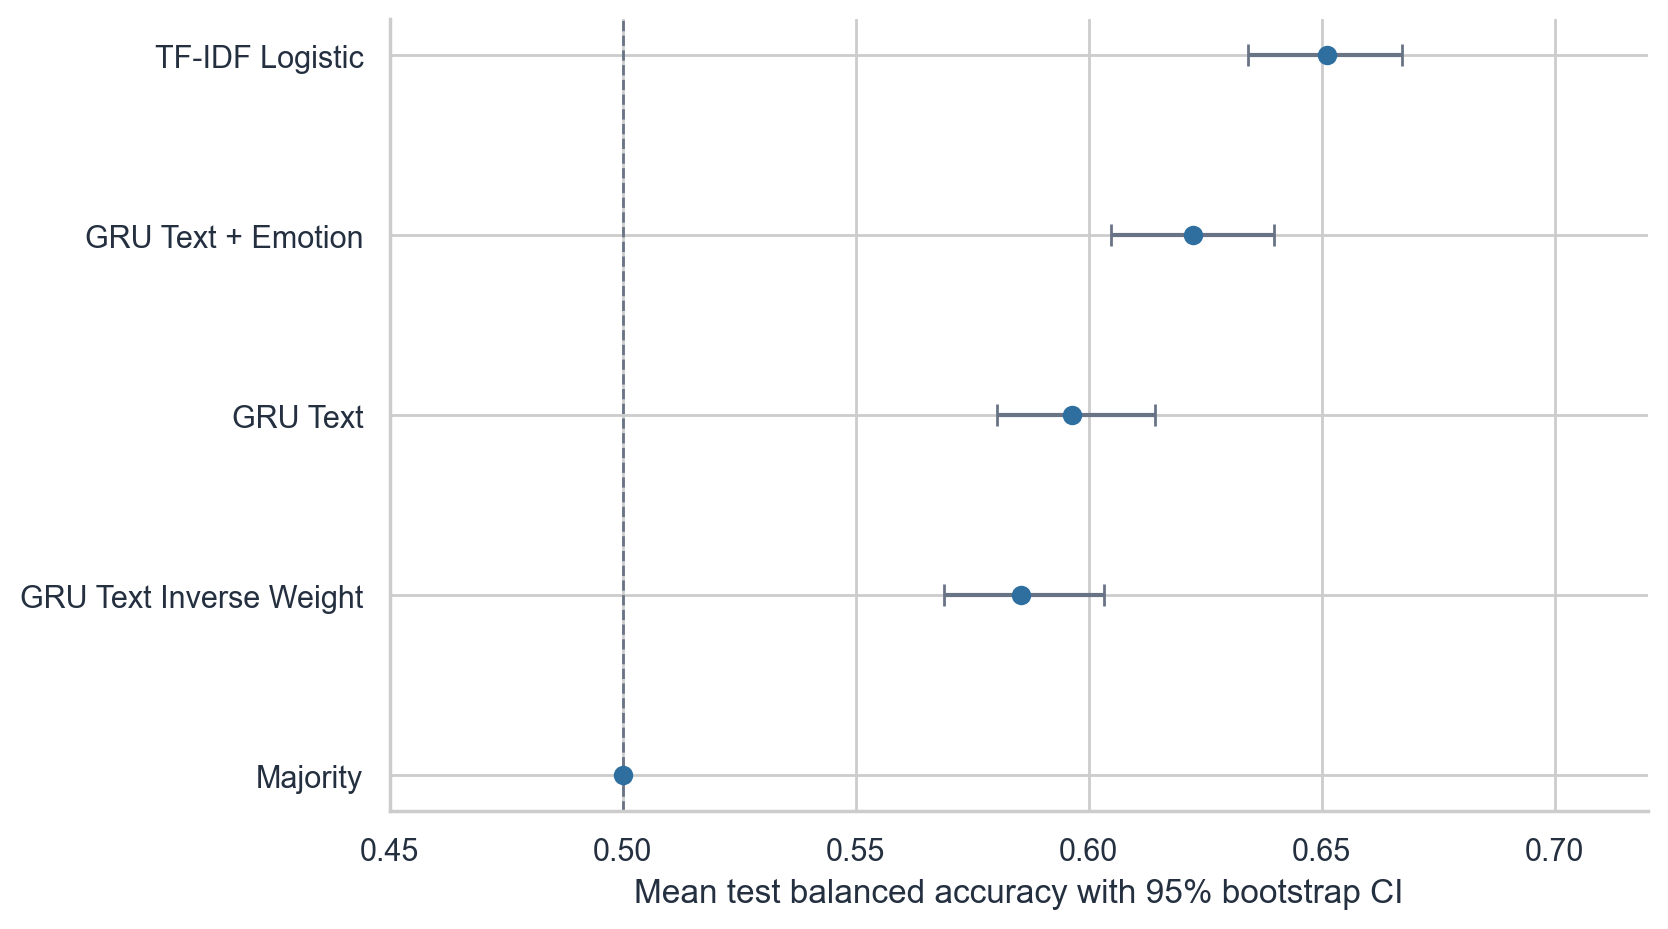

,target,threshold_objective,selected_threshold,validation_objective_score,test_balanced_accuracy,test_f1
0,target_E,balanced_accuracy,0.350,0.6466,0.6119,0.4004
1,target_E,f1,0.350,0.4388,0.6119,0.4004
2,target_S,balanced_accuracy,0.215,0.6117,0.5652,0.1485
3,target_S,f1,0.225,0.1951,0.5641,0.1688
4,target_T,balanced_accuracy,0.455,0.7047,0.6929,0.6369
5,target_T,f1,0.450,0.6570,0.6993,0.6520
6,target_J,balanced_accuracy,0.445,0.6158,0.6191,0.5484
7,target_J,f1,0.435,0.5970,0.5729,0.5900


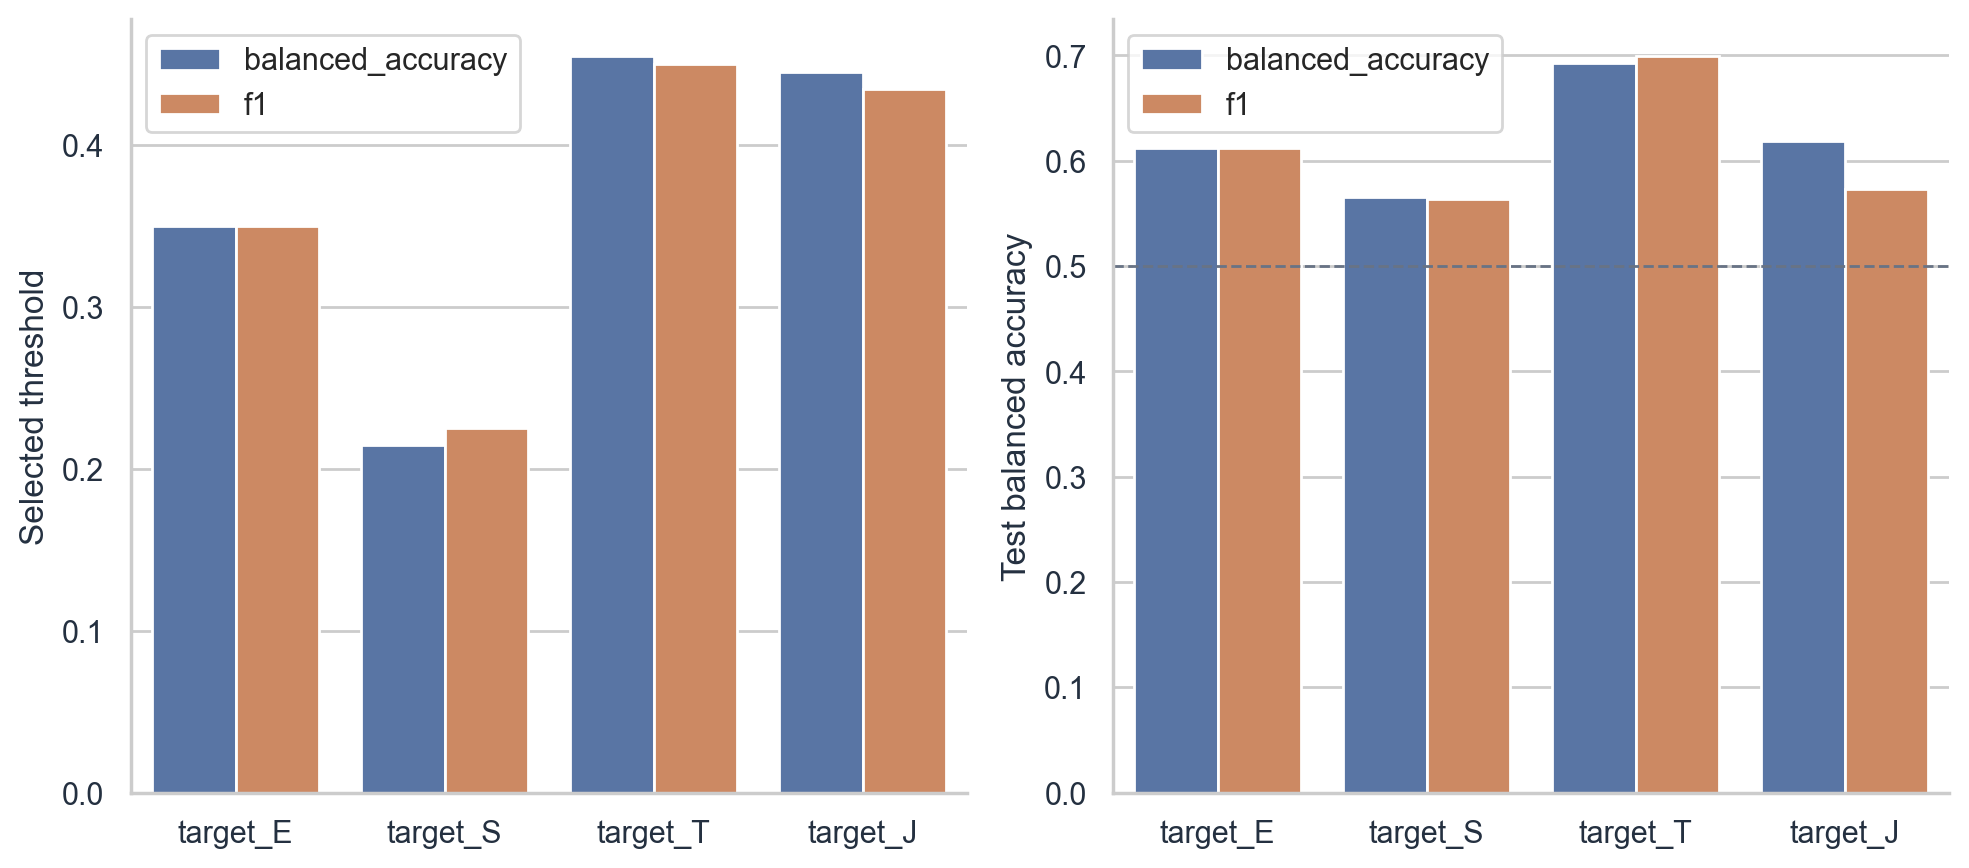

In [14]:
bootstrap_intervals = pd.read_csv(REPORT_RESULTS_DIR / "bootstrap_model_intervals.csv")
bootstrap_differences = pd.read_csv(REPORT_RESULTS_DIR / "bootstrap_pairwise_differences.csv")

balanced_accuracy_ci = bootstrap_intervals.loc[
    bootstrap_intervals["metric"] == "balanced_accuracy",
    ["model_name", "point_estimate", "ci_lower", "ci_upper", "n_test_authors", "n_bootstrap"],
].sort_values("point_estimate", ascending=False)

display(balanced_accuracy_ci.style.format({
    "point_estimate": "{:.4f}",
    "ci_lower": "{:.4f}",
    "ci_upper": "{:.4f}",
}))
show_png("fig_bootstrap_balanced_accuracy_ci.png")

threshold_sensitivity = pd.read_csv(REPORT_RESULTS_DIR / "threshold_objective_sensitivity.csv")
display(threshold_sensitivity.style.format({
    "selected_threshold": "{:.3f}",
    "validation_objective_score": "{:.4f}",
    "test_balanced_accuracy": "{:.4f}",
    "test_f1": "{:.4f}",
}))
show_png("fig_threshold_objective_sensitivity.png")


These diagnostics explain the evaluation choices. Validation-tuned thresholds and balanced accuracy are needed because class imbalance can make raw accuracy misleading. The bootstrap intervals also show why small differences should be interpreted as uncertainty-bounded evidence rather than as absolute rankings.

## 14. Final Takeaways

The main result is a modeling result, not a claim that one feature solves MBTI prediction. The model has to match the unit of the label: MBTI is self-reported at the author level, so the strongest approach represents each author as a set of posts and evaluates only on held-out authors.

**Robust finding.** The strongest evidence supports **author-level set/attention modeling**. The p200 set/attention family outperforms TF-IDF, frozen MiniLM summary probes, and corrected GRU baselines. The post-budget results show that using more author history is central to the gain, and the controls run shows that activity/length information is an important diagnostic to keep in the comparison.

**Cautious finding.** Emotion-derived features remain scientifically interesting, but the evidence does not support a strong standalone emotion claim. In the main p200 run, real emotion underperforms text-only and the paired bootstrap point estimate is negative, though its interval crosses zero; under larger max-epoch caps, shuffled emotion improves more than real emotion. The defensible interpretation is that emotion probabilities act as text-derived transferred features whose incremental value is not robustly separated from text-only or shuffled controls.

**What the results do not show.** These experiments do not show that true emotional state causally determines MBTI type. The emotion channel is a transferred text representation, and the source-to-Reddit distribution shift plus shuffled-control results require caution.

The final methodological contribution is the author-level formulation with scientific controls: author-level splits, validation-tuned thresholds, shuffled-emotion negative controls, post-budget sensitivity, stability checks, and paired deltas computed only on held-out authors.

## Full Reproduction Commands

The notebook does not launch full training during `Run All`; doing so would make the review path slow and hardware-dependent. The actual modeling jobs are run through scripts, and this notebook reads the compact CSV/PNG outputs after `aggregate_report_results.py` rebuilds `report/results`.

From `milestones/ms4_final_modeling_deliverables/code`, the core full pipeline is:

```bash
uv sync --extra full --extra dev
uv run --extra full python scripts/preprocess_reddit_ms4.py
uv run --extra full python scripts/run_author_baselines.py
uv run --extra full python scripts/cache_emotion_features.py --output-path artifacts/cache/emotion_probs_full.parquet --batch-size 256 --log-every-batches 100
uv run --extra full python scripts/train_stage2_text_gru.py --full-run
uv run --extra full python scripts/train_stage2_text_gru.py --full-run --run-id stage2_text_gru_inverse_full --pos-weight-variant inverse
uv run --extra full python scripts/train_stage2_text_gru.py --full-run --run-id stage2_text_emotion_gru_full --emotion-feature-path artifacts/cache/emotion_probs_full.parquet
uv run --extra full python scripts/train_stage2_text_gru.py --full-run --run-id stage2_text_gru_len256_full --max-length 256 --pos-weight-variant sqrt
uv run --extra full python scripts/cache_transformer_embeddings.py
uv run --extra full python scripts/run_transformer_author_models.py --embedding-cache-dir artifacts/cache/transformer_embeddings/sentence-transformers__all-MiniLM-L6-v2_max256
uv run --extra full python scripts/run_set_attention_author_models.py --full-run --embedding-cache-dir artifacts/cache/transformer_embeddings/sentence-transformers__all-MiniLM-L6-v2_max256
uv run --extra full python scripts/aggregate_report_results.py
```

The supplemental p200 set/attention runs use the same `run_set_attention_author_models.py` entry point with `--post-budgets 200`, explicit `--seed`, explicit `--epochs`, `--skip-pooling`, and the three variants `set_attention_text`, `set_attention_text_real_emotion`, and `set_attention_text_shuffled_emotion`. The training script fixes the global seed, passes a seeded PyTorch `DataLoader` generator, and standardizes post-level control columns using train-split statistics within each post-budget setting. Those runs are aggregated into the seed-stability and max-epoch-cap sensitivity tables shown above.


## Reproducibility Notes

- Runtime: the Python environment is specified in `pyproject.toml` and `uv.lock`; the submitted notebook path loads prepared result tables and figures rather than rerunning long training jobs.
- Training entry points: preprocessing, emotion caching, transformer embedding caching, GRU training, transformer-author training, and report aggregation are implemented as scripts under `scripts/` and listed above.
- Data source: Reddit MBTI dataset loaded through KaggleHub, with MBTI leakage masking before modeling.
- Emotion features: DistilBERT-style emotion probabilities applied to Reddit posts and treated as text-derived transferred representations.
- Main metric: author-level mean balanced accuracy over `E/I`, `N/S`, `F/T`, and `J/P` dimensions.
- Excluded mainline experiment: supervised post-level transformer fine-tuning, because it changes the estimand and reintroduces noisy post-level MBTI labels.


## References and Assistance

- Reddit MBTI target data: Kaggle dataset `minhaozhang1/reddit-mbti-dataset`.
- Emotion source data: Hugging Face dataset `AdamCodd/emotion-balanced`.
- Frozen text representations: Hugging Face Transformers encoder `sentence-transformers/all-MiniLM-L6-v2` with manual mean pooling.
- Core software: pandas, scikit-learn, PyTorch, Hugging Face Transformers, matplotlib/seaborn, and Jupyter.
- Generative AI assistance was used for coding support, notebook organization, and prose revision; final experimental choices, verification, and interpretation remain the team's responsibility.
